# Disinformation detection using graph neural networks: a survey — a working replication

Lakzaei, B.; Haghir Chehreghani, M.; Bagheri, A.
***Artificial Intelligence Review*** (2024) **57**:52.
<https://doi.org/10.1007/s10462-024-10702-9>

---

## Read this first: what it means to "replicate" a survey

This paper is a **survey**. That single fact shapes everything below, so let us
be honest about it up front:

- It reports **no experiments of its own**.
- It has **no code release**, and could not have one — nothing was run.
- Its **six figures are all diagrams**: a framework block diagram, a GNN
  schematic, and four taxonomy trees. There is not a single data plot in the
  paper.
- Its tables are a **meta-analysis**: Tables 1–2 record what 34 *other* papers
  reported; Table 3 characterises 10 datasets; Table 4 shows sample records.

So "reproduce Figure 3" cannot mean "rerun their script". This notebook takes
replication to mean three concrete, checkable things.

### 1. Reproduce the six figures — from data, not by tracing

Every taxonomy is encoded as a **structure** (`disinfo.taxonomy`) and *rendered*
(`disinfo.plots`). The figure is therefore a view of data we can query, not a
picture we copied. Figure 3 goes furthest: its computation tree is **unrolled
from the adjacency matrix**, so if our reading of message passing were wrong,
the picture would visibly disagree with the paper.

### 2. Test the survey's own claims against the survey's own tables

Section 5.3.2 draws four conclusions from Tables 1–2 **in prose**, and plots
none of them. Section 7 makes a fifth. We transcribe the tables, state each
conclusion as a predicate, and evaluate it.

> **Five of the six hold. One is contradicted by the paper's own tables.**
> We will find it in Part 2.

### 3. Actually run the framework the survey describes

Section 3.1 gives five GNN update rules as equations (2–10). Section 5.3 gives
three graph constructions. Figure 1 gives a four-stage pipeline. All of that
*is* specified precisely enough to implement — so we implement it from the
equations and run it on four real datasets.

---

## How this notebook is organised

| Part | What happens | Paper section |
|---|---|---|
| 0 | Setup; the package layout | — |
| 1 | Reproduce Figures 1–6 from encoded taxonomies | Figs. 1–6 |
| 2 | **Meta-analysis**: test the survey's prose against its tables | Tables 1–2, Sects. 5.3.2, 7 |
| 3 | **The equations**: Eqs. 1–10 derived, implemented, property-checked | Sect. 3.1 |
| 4 | The datasets, and verifying Table 3 against reality | Sect. 6, Table 3 |
| 5 | Stage 1 — feature extraction | Sect. 4, Fig. 4 |
| 6 | Stage 2 — graph construction (the survey's novel axis) | Sect. 5.3 |
| 7 | Stages 3–4 — GNN and classification, end to end | Sects. 3, 5.1 |
| 8 | Five experiments testing five specific claims | Sects. 5.3.2, 7 |
| 9 | This replication against the published range | Tables 1–2 |
| 10 | What we learned; the open problems of Section 7 | Sect. 7 |

**Nothing scientific lives in this notebook.** Every computation imports from
the `disinfo` package at the repository root, so the same code is testable
outside Jupyter. The notebook explains and calls; the package computes.

---

## Running it

```bash
# 1. environment (already built if you are reading this from the repo)
python3 -m venv 01-info-propagation/desinformation-paper/.venv
01-info-propagation/desinformation-paper/.venv/bin/pip install \
    torch numpy scipy networkx scikit-learn matplotlib pandas tqdm jupyter ipykernel

# 2. data (~370 MB: LIAR, Twitter15/16, PHEME, and CED reused from the entropia paper)
bash scripts/get_disinfo_data.sh

# 3. everything, headless
01-info-propagation/desinformation-paper/.venv/bin/python \
    scripts/run_disinfo.py --quiet --experiments
```

Parts 0–7 run in a couple of minutes. Part 8 trains models and takes longer; it
is written so you can read the pre-computed results instead of re-running.

---
# Part 0 — Setup

The replication lives in `disinfo/` at the repository root, a sibling of
`dtwre/` (the earlier Rényi-entropy replication). Layering is strict and
one-directional:

```
config, taxonomy, survey_data     no dependencies on the rest
        ↓
layers  →  checks                 Eqs. 2–10 and their property tests
        ↓
data  →  features  →  graphs      Fig. 1 stages 1 and 2
        ↓
models  →  pipeline               Fig. 1 stages 3 and 4
        ↓
experiments  →  plots
```

In [1]:
import sys, warnings
from pathlib import Path

# The notebook lives two levels below the repository root.
ROOT = Path.cwd()
while not (ROOT / "disinfo").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 90)

import disinfo
from disinfo import Config, plots

plots.setup_style()

print(f"repository root : {ROOT}")
print(f"disinfo version : {disinfo.__version__}")
print(f"torch           : {torch.__version__}")
for k, v in disinfo.PAPER.items():
    print(f"{k:9s}: {v}")

repository root : /Users/alberto/Documents/projects/renyi
disinfo version : 1.0.0
torch           : 2.13.0
title    : Disinformation detection using graph neural networks: a survey
authors  : Batool Lakzaei, Mostafa Haghir Chehreghani, Alireza Bagheri
venue    : Artificial Intelligence Review (2024) 57:52
doi      : 10.1007/s10462-024-10702-9
accepted : 2024-01-04
kind     : survey (no original experiments, no code release)


---
# Part 1 — Reproducing Figures 1–6

All six figures are diagrams. We encode each as a data structure and render it.
The benefit is not aesthetic: a structure can be **queried**, so the taxonomy
stops being a picture you squint at and becomes something you can ask questions
of.

## Figure 1 — the general framework

Section 1 breaks disinformation detection with GNNs into four stages. This is
the spine of the whole notebook: Parts 5, 6 and 7 implement stages 1, 2 and 3–4
respectively.

findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


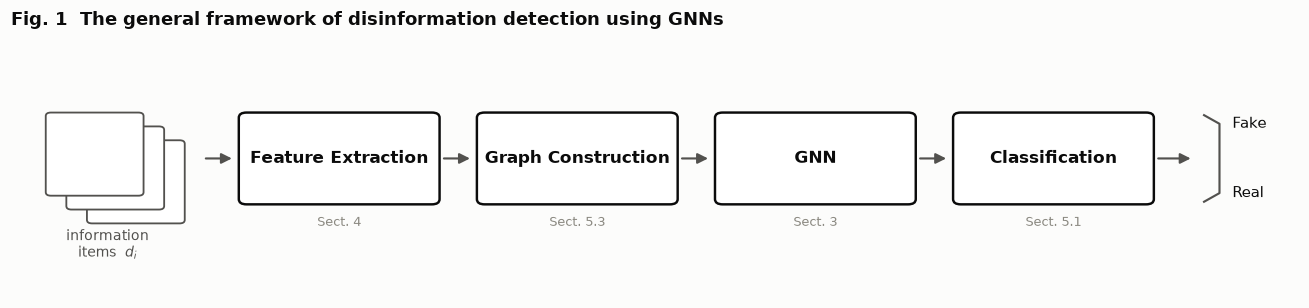

1. Feature Extraction   (Sect. 4)
   Initial feature vectors: textual, visual, and so on, via linguistic models and CNNs.
2. Graph Construction   (Sect. 5.3)
   Similarity graph, propagation graph, or heterogeneous graph.
3. GNN                  (Sect. 3)
   An embedding per node, capturing local structure and content.
4. Classification       (Sect. 5.1)
   Embeddings into a classifier; output binary (fake/real) or multiclass (true/false/unverified/non-rumor).


In [2]:
fig = plots.fig1_framework()
plt.show()

for i, stage in enumerate(disinfo.taxonomy.FIG1_STAGES, 1):
    print(f"{i}. {stage['name']:20s} (Sect. {stage['section']})")
    print(f"   {stage['detail']}")

## Figure 2 — types of false information

Section 2 is a glossary, and the distinctions it draws are not pedantic. The
split that matters most is **misinformation vs disinformation**, and it is
*intent*, not truth value:

- **Misinformation** — false, but an honest mistake. *Not intended to deceive.*
- **Disinformation** — false, and **spread deliberately to mislead**.

Note where **satire** sits: under misinformation, because it has no harmful
intention even though it can deceive. And note that **rumour** is *not
necessarily false* — it is merely unverified, and may later be confirmed. That
is why rumour datasets like PHEME and Twitter15/16 carry a four-way label
(`true / false / unverified / non-rumor`) rather than a binary one.

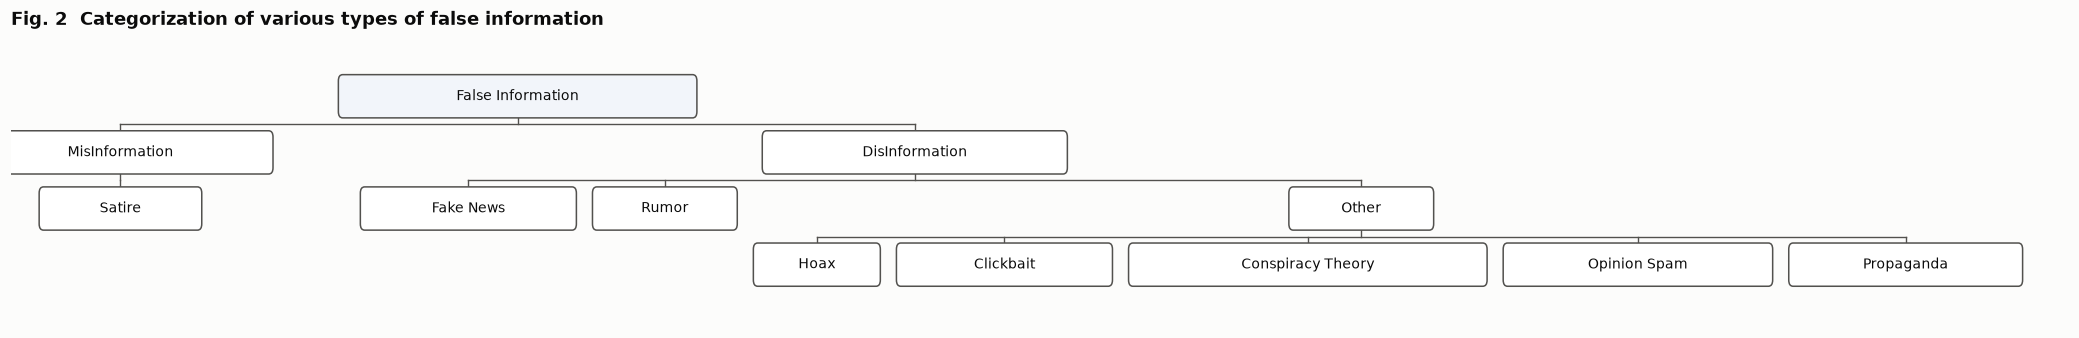

False Information
    MisInformation
        Satire
    DisInformation
        Fake News
        Rumor
        Other
            Hoax
            Clickbait
            Conspiracy Theory
            Opinion Spam
            Propaganda

--- Section 2 definitions ---

False Information
    content that contains false and untrue information, written for different purposes.

MisInformation
    false, mistaken, or misleading information that is often considered honest mistake... The purpose of misinformation is not to deceive the audience.

DisInformation
    false information that is spread deliberately to mislead and deceive.

Satire
    an article that incorporates cleverly crafted allusions. It does not have a harmful intention, but there is a potential for deception.

Fake News
    news articles that are intentionally and verifiably false.

Rumor
    information that has not yet been confirmed by official resources... not necessarily incorrect.

Hoax
    messages sent to a wide range of

In [3]:
fig = plots.fig2_false_information()
plt.show()

# Because it is a structure, we can print it as an accessible tree with the
# Section 2 definitions attached.
from disinfo.taxonomy import FIG2_FALSE_INFORMATION, FIG2_DEFINITIONS, describe, path_to

print(describe(FIG2_FALSE_INFORMATION))
print("\n--- Section 2 definitions ---")
for term, definition in FIG2_DEFINITIONS.items():
    print(f"\n{term}\n    {definition}")

In [4]:
# Queries a picture cannot answer:
print("Where does 'Satire' sit?        ", " > ".join(path_to(FIG2_FALSE_INFORMATION, "Satire")))
print("Where does 'Clickbait' sit?     ", " > ".join(path_to(FIG2_FALSE_INFORMATION, "Clickbait")))
print("\nSo satire is a kind of MISinformation (no intent to harm),")
print("while clickbait is a kind of DISinformation (deliberate).")

Where does 'Satire' sit?         False Information > MisInformation > Satire
Where does 'Clickbait' sit?      False Information > DisInformation > Other > Clickbait

So satire is a kind of MISinformation (no intent to harm),
while clickbait is a kind of DISinformation (deliberate).


## Figure 3 — the general scheme of a GNN

This figure has two halves. On the left, a five-node graph with the
neighbourhood of node `a` circled. On the right, the **computation tree** for
`a` under a 3-layer GNN.

The right-hand side is the one worth dwelling on, because it is where people's
intuition usually breaks. A 3-layer GNN does not "look at the graph three
times". It builds a *tree of receptive fields*: to compute `a` at layer 3 you
need `a`, `b` and `c` at layer 2; to get `b` at layer 2 you need `b`, `a` and
`d` at layer 1; and so on. The tree grows as $O(\deg^L)$ and nodes reappear at
multiple positions.

**We generate this tree by unrolling the adjacency**, not by transcribing the
paper's picture. So it doubles as a check on our reading of Eq. 1.

findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


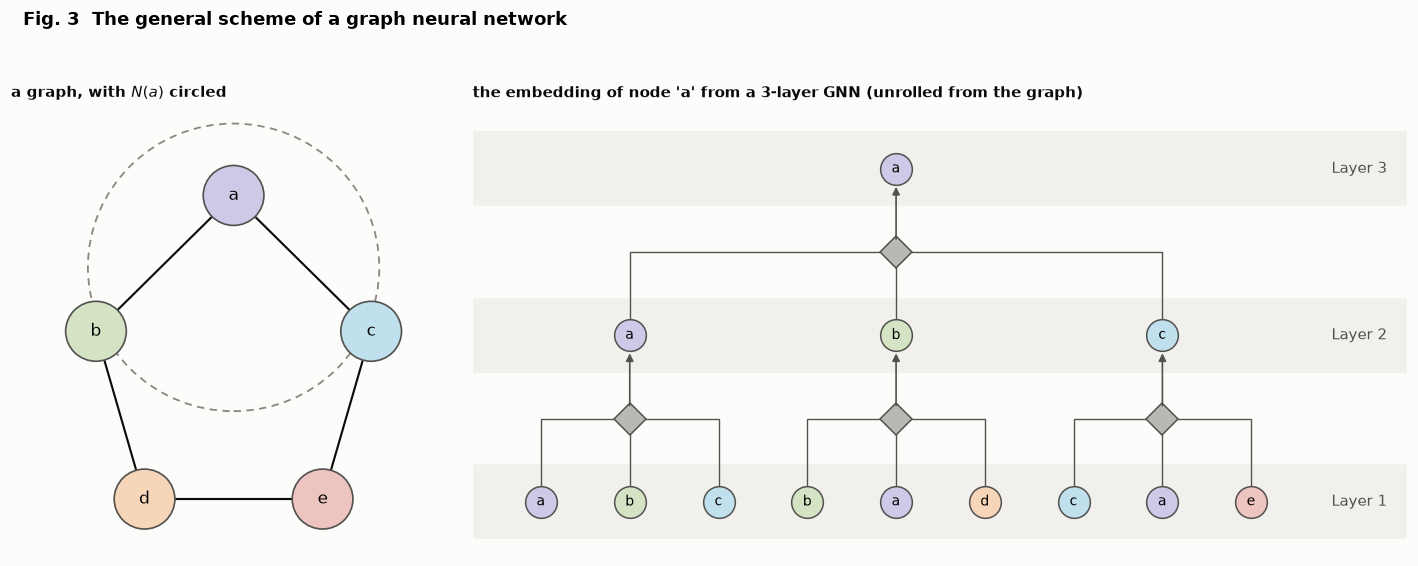

Layer 1: a b c b a d c a e
Layer 2: a b c
Layer 3: a

Matches the paper's Fig. 3 exactly (a b c | b a d | c a e).


In [5]:
fig = plots.fig3_gnn_schematic()
plt.show()

# Verify the unrolling matches the paper's Figure 3 exactly.
from disinfo.taxonomy import FIG3_EXAMPLE

spec = FIG3_EXAMPLE
adj = {n: [] for n in spec["nodes"]}
for a, b in spec["edges"]:
    adj[a].append(b); adj[b].append(a)

levels = [[spec["root"]]]
for _ in range(spec["layers"] - 1):
    levels.append([m for v in levels[-1] for m in [v] + sorted(adj[v])])
levels.reverse()

for i, level in enumerate(levels, 1):
    print(f"Layer {i}: {' '.join(level)}")

assert levels[0] == list("abc") + list("bad") + list("cae"), "unrolling mismatch"
print("\nMatches the paper's Fig. 3 exactly (a b c | b a d | c a e).")

## Figure 4 — types of features

Section 4's taxonomy of features. The top split is the one the whole field turns
on:

- **Content-based** — what the item *says* (text, images, semantics).
- **Context-based** — what the *network does with it* (who posted it, who
  reposted it, when, and what they said about it).

Section 4.1 gives the reason content alone is not enough, and it is an
adversarial one: *"writers of disinformation are aware of these features and
often attempt to mimic the structure and writing style of genuine
information."* Style is a cat-and-mouse game. Propagation structure is much
harder for an author to fake, because it is produced by other people.

The trade-off, stated in Section 5.2.3: context-based methods **cannot detect
early**, because there is no cascade yet. That tension drives the hybrid methods
at the top of Tables 1–2.

*(The published figure spells one leaf "Commnet"; we render the correction.)*

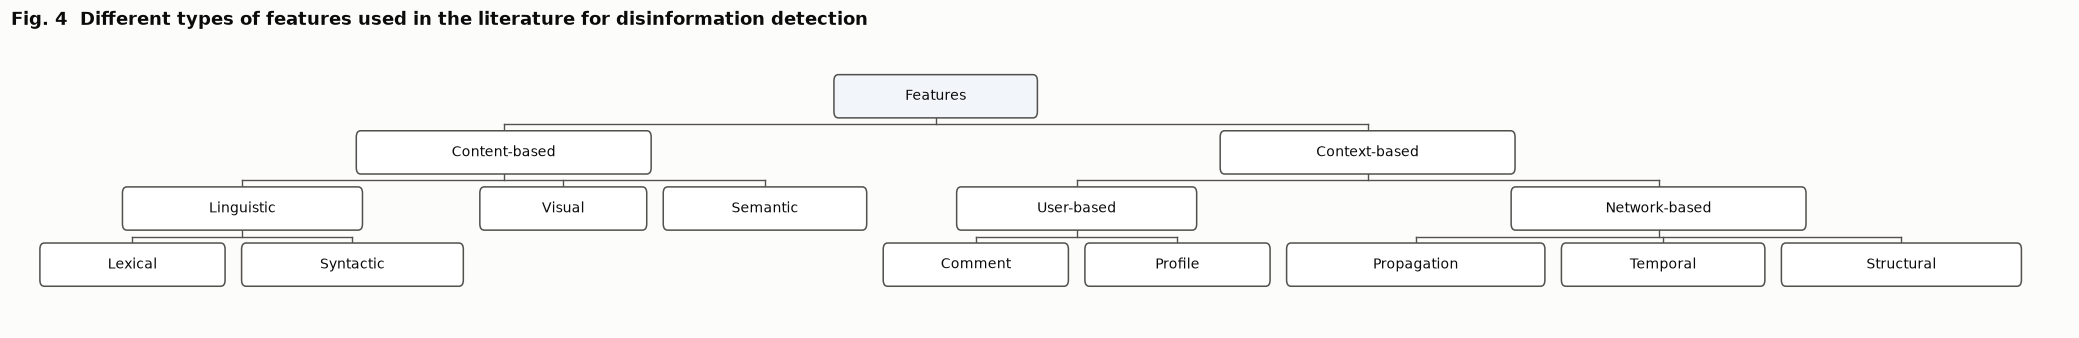

Features
    Content-based
        Linguistic
            Lexical
            Syntactic
        Visual
        Semantic
    Context-based
        User-based
            Comment
            Profile
        Network-based
            Propagation
            Temporal
            Structural

Leaf feature types: Lexical, Syntactic, Visual, Semantic, Comment, Profile, Propagation, Temporal, Structural


In [6]:
fig = plots.fig4_features()
plt.show()

from disinfo.taxonomy import FIG4_FEATURES, leaves
print(describe(FIG4_FEATURES))
print("\nLeaf feature types:", ", ".join(n.label for n in leaves(FIG4_FEATURES)))

## Figures 5 and 6 — the two categorisations

These are the survey's stated original contributions: *"For the first time, we
categorize disinformation detection methods from two perspectives: features and
algorithms."*

**Figure 5 (by strategy)** splits first into **detection** (find it after the
fact) versus **intervention** (stop the agents that spread it — bad sources, bad
users). Section 5.2.3 is candid about why detection dominates: intervention
"could result in substantial user dissatisfaction" if it misfires. Deleting an
innocent person's account is a worse failure than mislabelling a post.

**Figure 6 (by algorithm)** descends from ML/non-ML down to the GNN leaf, and it
is here that the survey's novel axis appears — GNN methods are split by **how
the graph is built** (similarity / propagation / heterogeneous), not by
architecture. Part 6 tests whether that axis actually predicts performance.

In both figures `[i]-j` means reference *i*, published in year *j*; a trailing
`...` is the authors' own truncation.

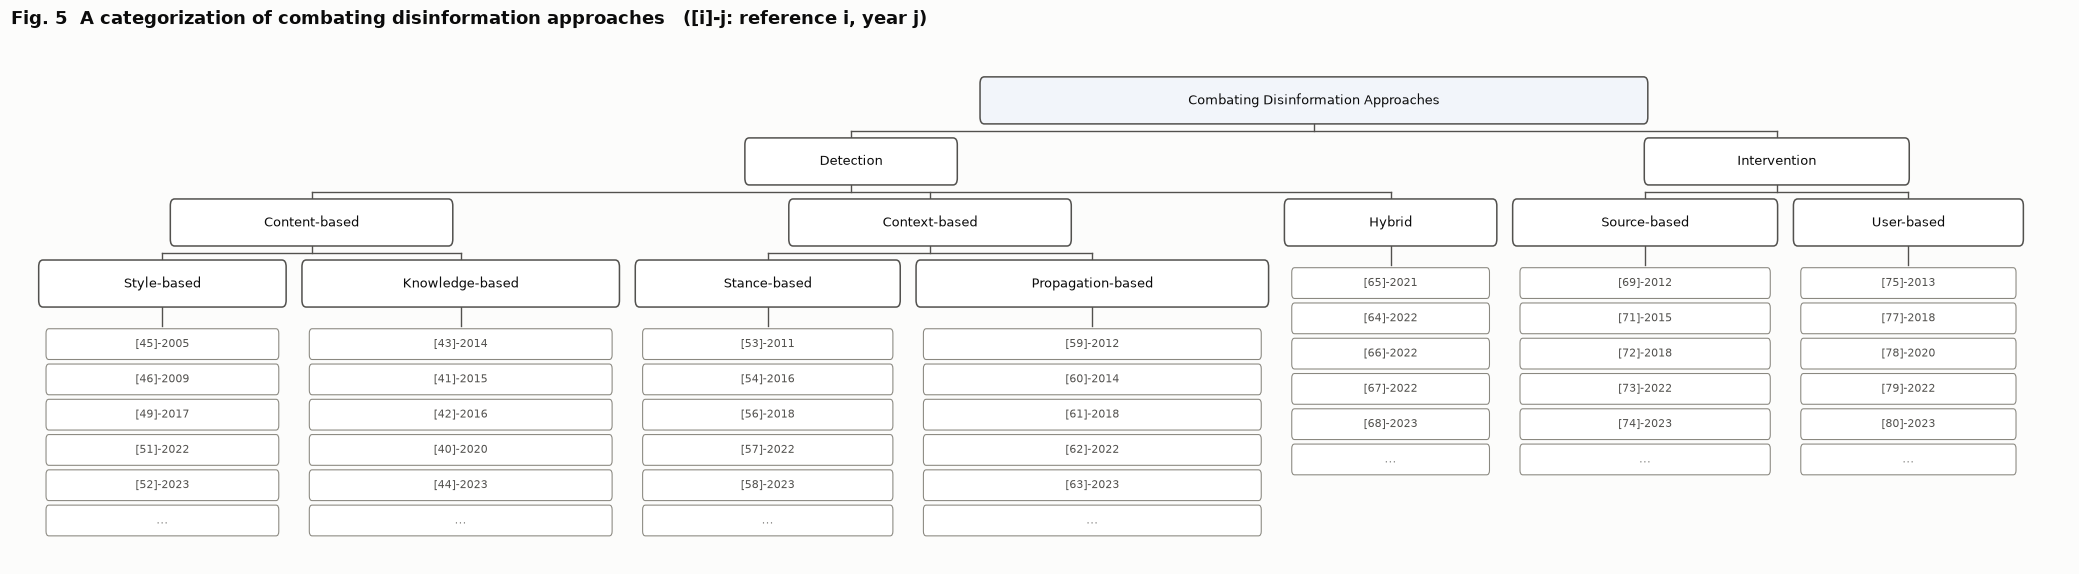

In [7]:
fig = plots.fig5_approaches()
plt.show()

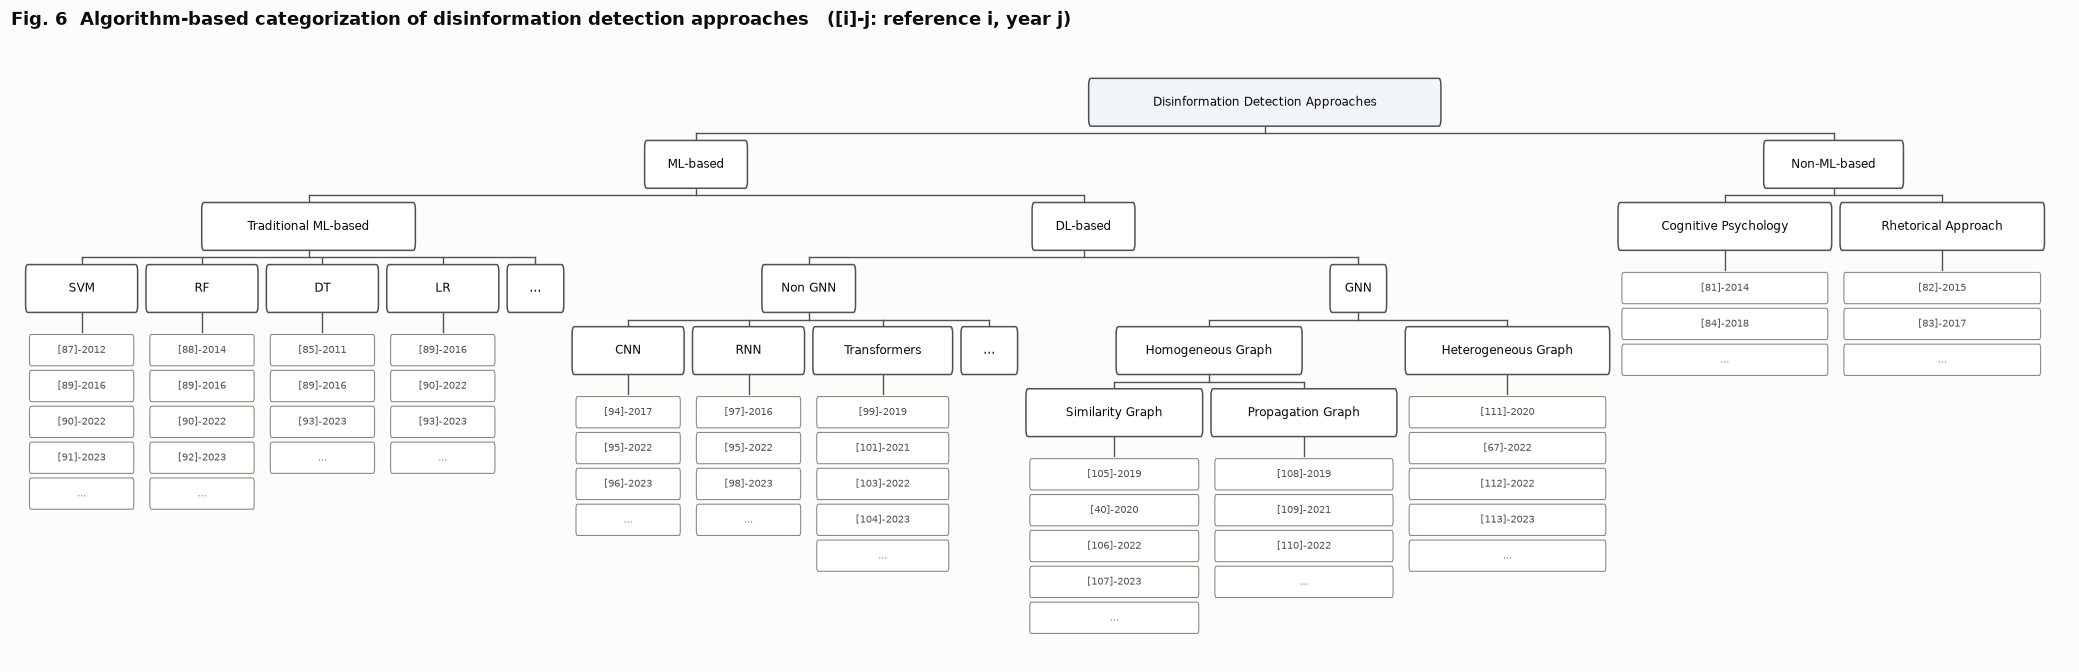

Path to the GNN leaves of Fig. 6:
  Disinformation Detection Approaches > ML-based > DL-based > GNN > Homogeneous Graph > Similarity Graph
  Disinformation Detection Approaches > ML-based > DL-based > GNN > Homogeneous Graph > Propagation Graph
  Disinformation Detection Approaches > ML-based > DL-based > GNN > Heterogeneous Graph


In [8]:
fig = plots.fig6_algorithms()
plt.show()

from disinfo.taxonomy import FIG6_ALGORITHMS
print("Path to the GNN leaves of Fig. 6:")
for leaf in ["Similarity Graph", "Propagation Graph", "Heterogeneous Graph"]:
    print("  " + " > ".join(path_to(FIG6_ALGORITHMS, leaf)))

---
# Part 2 — The meta-analysis the survey implies but never draws

Here is the heart of what *can* be replicated in a survey.

Tables 1 and 2 record 34 GNN-based methods across ten columns. Section 5.3.2
then draws four conclusions from them, **in prose, with no plot**:

> - GNN is a novel technique... with its first research being presented in 2019.
> - GCN and GAT stand out as the most widely utilized graph neural networks.
> - The majority of methods employ the propagation graph...
> - The majority of methods rely on textual features... comments, semantic
>   characteristics and temporal aspects have been given less consideration.
> - Most methods are based on supervised learning...

Section 7 adds a fifth:

> - in this setting [multiclass] existing algorithms suffer from relatively low
>   accuracy rates, **typically below 50%**.

We transcribed both tables into `disinfo.survey_data` and stated each claim as a
predicate. Now we check them.

In [9]:
methods = disinfo.methods_table()
print(f"Tables 1-2 transcribed: {len(methods)} methods, "
      f"{len(disinfo.long_results())} (method, dataset) results\n")
methods.head(10)

Tables 1-2 transcribed: 34 methods, 69 (method, dataset) results



,ref,year,cite_year,table,gnn,graph,features,approach,setting,disinfo_type,datasets,performance
0,Benamira et al.,2019,2019,1,"GCN, GAT",Similarity,Textual,Content-based,Semi-supervised,Fake news,Custom DS,Custom DS ACC: 0.849
1,Hu et al.,2019,2019,1,GCN,Similarity,"Textual, Profile",Content-based,Semi-supervised,Fake news,LIAR,LIAR ACC: 0.492
2,Autef et al.,2019,2020,1,"GCN, GAT, GraphSage",Propagation,"Textual, Profile",Context-based,Supervised,Fake news,"Twitter15, Twitter16",Twitter15 ACC: 0.690; Twitter16 ACC: 0.750
3,Huang et al.,2019,2019,1,GCN,Propagation,"Textual, Profile",Context-based,Supervised,Rumor,"Twitter15, Twitter16",Twitter15 ACC: 0.752; Twitter16 ACC: 0.773
4,Han et al.,2020,2020,1,GraphSage,Propagation,"Profile, Temporal",Context-based,Supervised,Fake news,"PolitiFact, GossipCop",PolitiFact ACC: 0.803; GossipCop ACC: 0.825
5,Bian et al.,2020,2020,1,GCN,Propagation,"Textual, Profile",Context-based,Supervised,Rumor,"Weibo, Twitter15, Twitter16",Weibo ACC: 0.961; Twitter15 ACC: 0.886; Twitter16 ACC: 0.880
6,Wang et al.,2020,2020,1,GCN,Similarity,"Textual, Visual, Semantic",Content-based,Supervised,Fake news,"Weibo, PHEME",Weibo ACC: 0.886; PHEME ACC: 0.876
7,Shang et al.,2020,2020,1,GCN,Similarity,Comments,Context-based,Supervised,Faux,"Reddit, Twitter",Reddit ACC: 0.754; Twitter ACC: 0.711
8,Zhiyuan et al.,2020,2020,1,GAT,Propagation,Textual,Context-based,Supervised,Rumor,PHEME,PHEME Macro-F1: 0.753
9,Bai et al.,2020,2021,1,GCN,Propagation,Textual,Context-based,Supervised,Rumor,PHEME,PHEME ACC: 0.841


In [10]:
# Transcription is not neutral. Everything ambiguous in the printed table is
# recorded rather than silently resolved.
for i, note in enumerate(disinfo.TRANSCRIPTION_NOTES, 1):
    print(f"{i}. {note}\n")

1. Table 1, Autef et al.: the Year column says 2019 but the reference is dated 2020. Both are kept, as `year` and `cite_year`.

2. Table 1, Bai et al.: Year column says 2020, reference dated 2021.

3. Table 1 row 'Song et al. (2021)' prints the dataset as 'FakeNewsNe', truncated in the PDF's column. Read as FakeNewsNet, matching the Table 2 row for the same authors.

4. Table 2, Cui et al.: LIAR ACC 0.868 is irreconcilable with Sect. 7's claim that multiclass accuracy is 'typically below 50%' and with the LIAR row of Table 1 (Hu et al., ACC 0.492). 0.868 is a plausible *binary* LIAR number and an implausible 6-class one. Flagged by `verify_claims`; see docs/DISCREPANCIES_SURVEY.md.

5. The 'Approach' column is the survey's content/context/hybrid axis of Fig. 5, not the graph type. Ren et al. and Huang et al. (2020) are labelled 'Content-based' while building heterogeneous graphs from user and propagation structure, which by the survey's own Sect. 4.2 definition is context. Transcribed 

## Testing the claims

In [11]:
claims = disinfo.verify_claims()

for _, r in claims.iterrows():
    mark = "SUPPORTED   " if r["supported"] else "CONTRADICTED"
    print(f"[{mark}] {r['claim']}  (Sect. {r['section']})")
    print(f"               {r['evidence']}\n")

print(f"=> {int(claims['supported'].sum())} of {len(claims)} claims supported "
      f"by the survey's own tables.")

[SUPPORTED   ] first_year_2019  (Sect. 5.3.2)
               earliest Year in Tables 1-2 is 2019 (Autef et al., Benamira et al., Hu et al., Huang et al.)

[SUPPORTED   ] gcn_gat_dominate  (Sect. 5.3.2)
               mentions: GCN=20, GAT=15, GraphSage=4, GGNN=1

[SUPPORTED   ] propagation_majority  (Sect. 5.3.2)
               Propagation=19/34 (56%); Propagation=19, Similarity=8, Heterogeneous=7

[SUPPORTED   ] textual_majority  (Sect. 5.3.2)
               Textual=32/34, Profile=17; Comments=5, Semantic=2, Temporal=5

[SUPPORTED   ] supervised_majority  (Sect. 5.3.2)
               Supervised=31/34; Supervised=31, Semi-supervised=3

[CONTRADICTED] multiclass_below_50  (Sect. 7)
               of 36 accuracies on multiclass datasets (LIAR, PHEME, Twitter15, Twitter16), 1 are below 0.5; median is 0.881

=> 5 of 6 claims supported by the survey's own tables.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


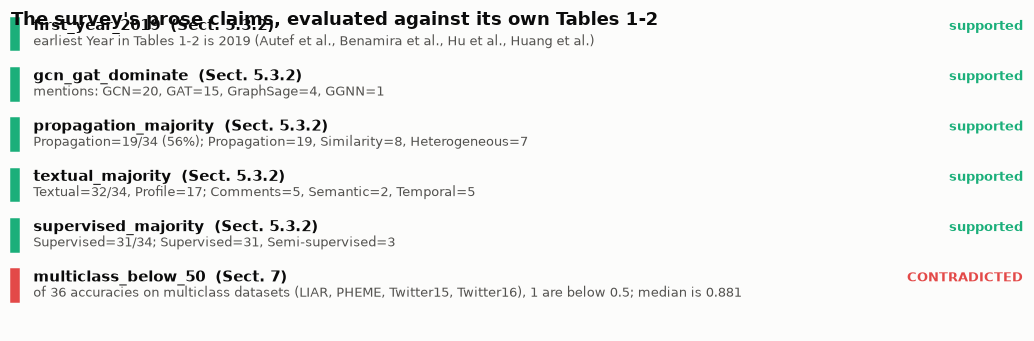

In [12]:
fig = plots.plot_claims(claims)
plt.show()

### The four supported claims, plotted

These are the figures Section 5.3.2 describes but does not draw.

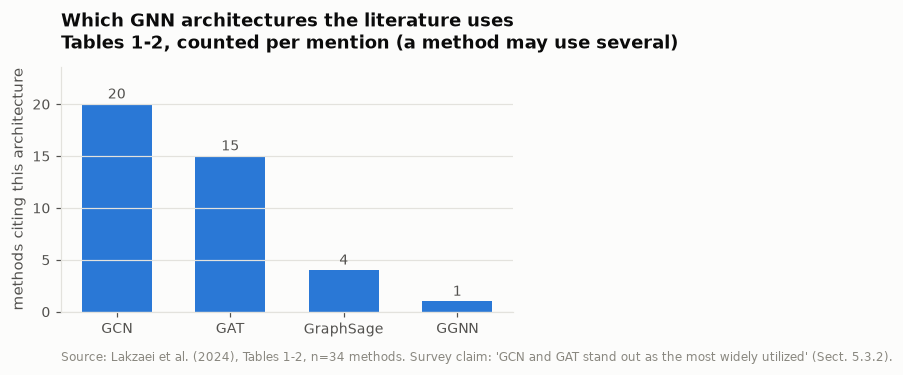

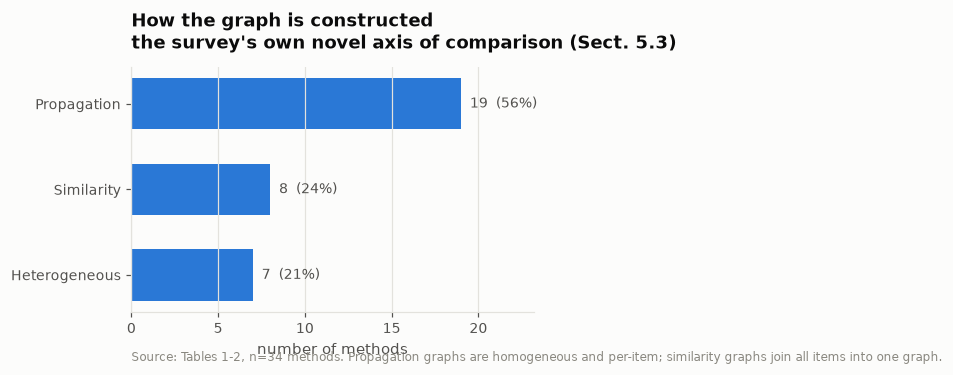

In [13]:
from disinfo.survey_data import METHODS
long_df = disinfo.long_results()

fig = plots.plot_gnn_usage(METHODS); plt.show()
fig = plots.plot_graph_type_usage(METHODS); plt.show()

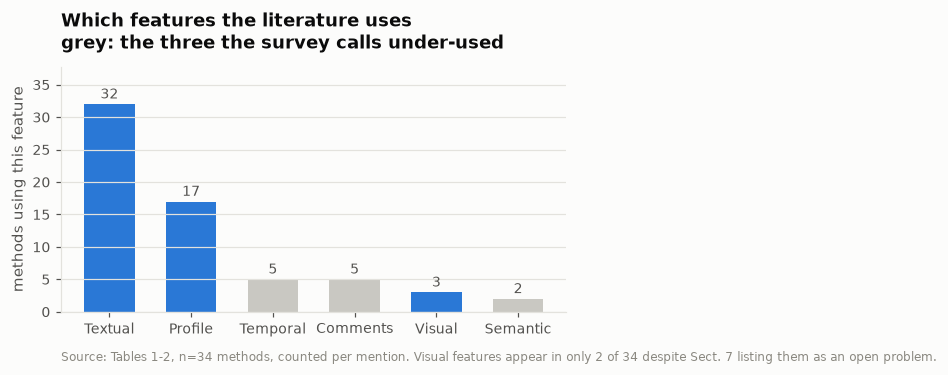

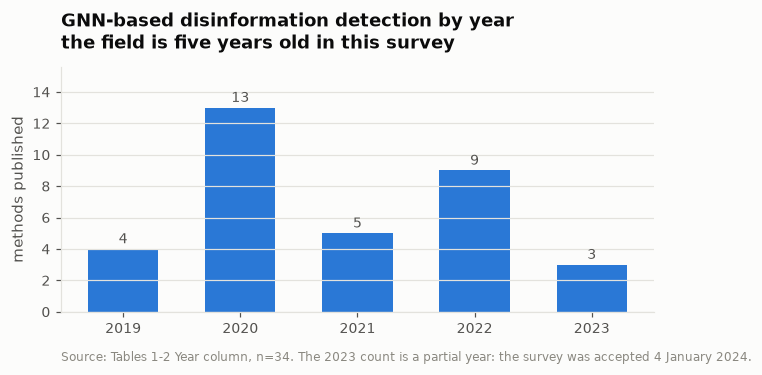

In [14]:
fig = plots.plot_feature_usage(METHODS); plt.show()
fig = plots.plot_year_trend(METHODS); plt.show()

Two things stand out that the prose passes over:

- **Visual features appear in only 2 of 34 methods**, even though Section 7
  lists them as an open problem and Section 4.1 argues images are how authors
  "elicit anger or other emotional responses". The field says images matter and
  then does not use them.
- **The 2023 bar is a partial year** — the survey was accepted 4 January 2024 —
  so the apparent decline after 2022 is a censoring artefact, not a trend.

### The contradicted claim

Section 7 says multiclass accuracy is "typically below 50%". The survey's own
Tables 1–2 contain 36 accuracies on datasets that Table 3 lists as 4- or
6-class. Let us look at every one of them.

In [15]:
multiclass = {d["name"] for d in disinfo.DATASETS if len(d["labels"]) > 2}
mc = long_df[long_df["dataset"].isin(multiclass) & (long_df["metric"] == "ACC")]

print(f"multiclass datasets in Table 3 : {sorted(multiclass)}")
print(f"accuracies reported on them    : {len(mc)}")
print(f"how many are below 0.50        : {(mc['value'] < 0.5).sum()}")
print(f"median                         : {mc['value'].median():.3f}")
print(f"range                          : {mc['value'].min():.3f} - {mc['value'].max():.3f}\n")
print(mc.nsmallest(5, "value")[["ref", "year", "dataset", "value"]].to_string(index=False))

multiclass datasets in Table 3 : ['BuzzFeed News', 'Fakeddit', 'LIAR', 'PHEME', 'Twitter15', 'Twitter16']
accuracies reported on them    : 36
how many are below 0.50        : 1
median                         : 0.881
range                          : 0.492 - 0.968

         ref  year   dataset  value
   Hu et al.  2019      LIAR  0.492
Autef et al.  2019 Twitter15  0.690
  Wei et al.  2022     PHEME  0.694
  Wei et al.  2021     PHEME  0.715
Autef et al.  2019 Twitter16  0.750


**One of 36.** The median is 0.881.

The single value below 0.5 is Hu et al. (2019) on **LIAR** — the only 6-class
dataset in the collection. The most charitable reading is that Section 7 is
describing LIAR specifically and over-generalises to all multiclass work. It is
an easy slip to make, and it matters, because that sentence is offered as
motivation for an entire open research direction.

We test this directly in **Part 8.4** by running 6-class and binary LIAR
side by side.

### A second internal contradiction

While we are here: Table 1 reports LIAR at **ACC 0.492** (Hu et al.), and Table 2
reports LIAR at **ACC 0.868** (Cui et al.). Both are printed as plain accuracy on
the same named dataset.

In [16]:
print(long_df[long_df["dataset"] == "LIAR"][["ref", "year", "gnn", "metric", "value"]]
      .to_string(index=False))

       ref  year  gnn metric  value
 Hu et al.  2019  GCN    ACC  0.492
Cui et al.  2023 GGNN    ACC  0.868


0.868 on 6-class LIAR would be far past the published state of the art (roughly
0.27–0.45). It is an unremarkable number for **binary** LIAR. Almost certainly
the two rows describe different tasks, and the survey does not say so — which is
exactly the "lack of a standardised benchmark" problem Section 7 complains about,
reproduced inside the survey itself.

### Which datasets carry the field's evidence, and how much they disagree

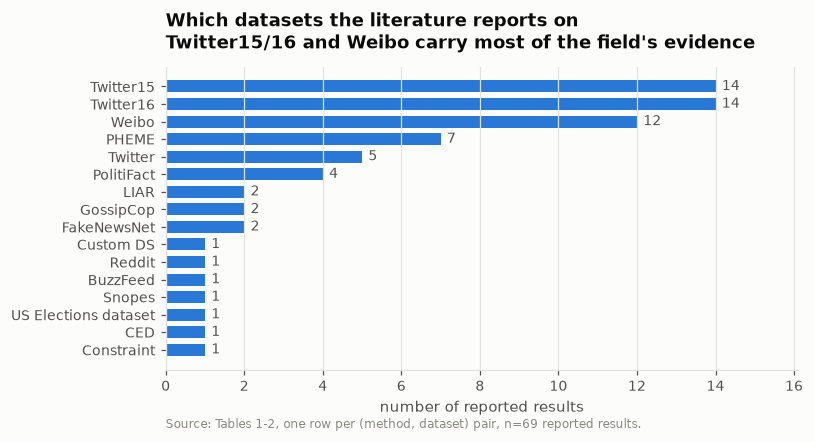

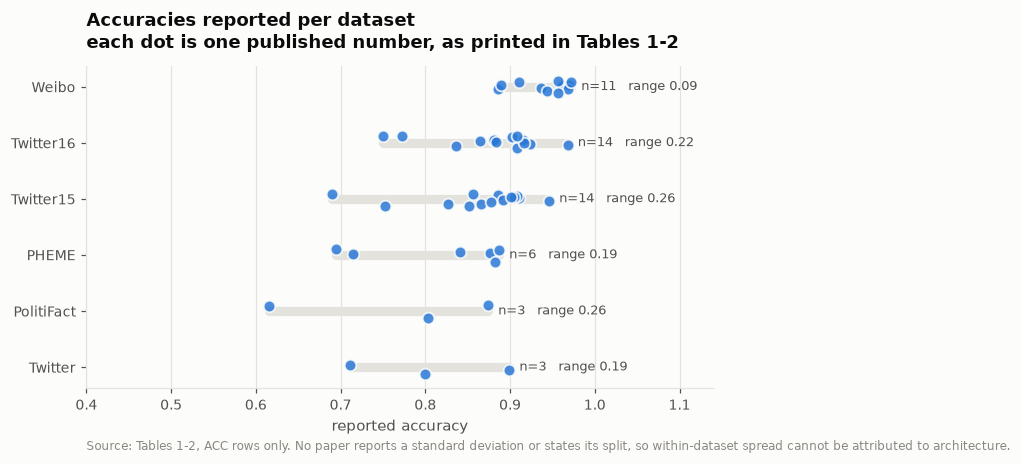

In [17]:
fig = plots.plot_dataset_usage(long_df); plt.show()
fig = plots.plot_reported_performance(long_df); plt.show()

Look at the **within-dataset spread**. On PHEME, published accuracies run from
0.694 to 0.887 — a range of 0.19. That is far wider than the difference between
any two architectures. Since **no paper in Tables 1–2 states its split protocol
or reports a standard deviation**, that spread cannot be attributed to method.

This is the central methodological finding of the meta-analysis, and Part 8.5
tests one candidate explanation directly.

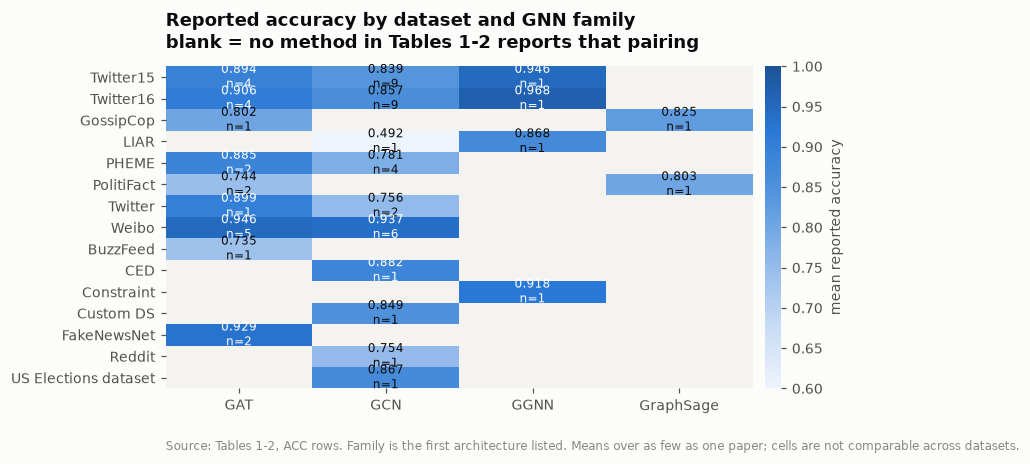

In [18]:
fig = plots.plot_performance_heatmap(long_df); plt.show()

The blank cells are the point. The field has covered a small fraction of the
(dataset × architecture) grid, and most cells that *are* filled rest on one or
two papers.

---
# Part 3 — The equations of Section 3.1

Now we leave meta-analysis and start building. Section 3.1 is the part of the
survey that is specified precisely enough to implement: five update rules,
Eqs. 2–10.

We implement each **from the printed equation**, then check it against a
property the mathematics must satisfy. The repository has no test suite by
convention — correctness is asserted against properties instead, which catches
the errors that "it ran without crashing" does not.

## Eq. 1 — the message-passing skeleton

$$h_v^{l} = \mathrm{UPDATE}\Big(h_v^{l-1},\ \mathrm{AGG}\big(\{h_u^{l-1} : u \in N(v)\}\big)\Big)$$

Every layer below is a choice of `AGG` and `UPDATE`. Three steps, per the paper:
gather neighbours' vectors, aggregate them, update your own.

**The one constraint that matters:** `AGG` takes a *set*, so it must be
permutation-invariant. If it is not, the layer is reading the node numbering —
an artefact of how the file was written — rather than the graph. We test this
first, and it is the check that catches the most bugs.

In [19]:
from disinfo.layers import (GCNLayer, GATLayer, GATv2Layer, SAGELayer, GINLayer,
                            scatter_sum, scatter_mean, scatter_softmax, degree)

# Graphs are (2, E) edge_index tensors: column (u, v) means "u sends to v",
# so edge_index[1] is always the receiver index used by every scatter.
edge_index = torch.tensor([[0, 1, 1, 2, 3],
                           [1, 0, 2, 1, 1]])
print("edge_index:\n", edge_index)
print("senders  :", edge_index[0].tolist())
print("receivers:", edge_index[1].tolist())
print("degrees  :", degree(edge_index, 4).tolist())

edge_index:
 tensor([[0, 1, 1, 2, 3],
        [1, 0, 2, 1, 1]])
senders  : [0, 1, 1, 2, 3]
receivers: [1, 0, 2, 1, 1]
degrees  : [1.0, 3.0, 1.0, 0.0]


## Eq. 2 — GCN, and a discrepancy

The survey prints, citing Welling & Kipf (2016):

$$h_v^{l} = \sigma\Big( W^{l-1} \sum_{u \in N(v) \cup \{v\}} \frac{h_u^{l-1}}{|N(v)|} \Big)$$

Read it carefully. The sum runs over $N(v) \cup \{v\}$ — that is $|N(v)|+1$
terms — but the denominator is $|N(v)|$. **This is not an average.** On a
$k$-regular graph with constant features it multiplies the signal by
$(k{+}1)/k$ every layer.

And it is not Kipf & Welling's rule either: they normalise symmetrically by
$\tilde{D}^{-1/2}\tilde{A}\tilde{D}^{-1/2}$, which divides by
$\sqrt{\deg(u)\deg(v)}$, not by $\deg(v)$ alone.

There is also a division by zero waiting for any isolated node — and isolated
nodes are routine here (a kNN graph at a high threshold, a PHEME thread with no
replies).

We implement **both** and let the notebook show the difference.

In [20]:
from disinfo.checks import check_gcn_normalization
print(check_gcn_normalization())

GCN preserves regularity; Eq.2 scales by 1.50 vs Kipf-Welling 1.00


On a 2-regular ring with constant input, the printed Eq. 2 returns **1.50** and
Kipf & Welling return **1.00** — the $(k{+}1)/k = 3/2$ factor, made concrete.

`normalization="symmetric"` is our default, because it is what every method in
Tables 1–2 that says "GCN" actually ran. `normalization="paper"` reproduces
Eq. 2 literally.

## Eqs. 3–4 — GAT, and a missing softmax

$$h_v^{l} = \Big\|_{k=1}^{K} \sigma\Big(\sum_{u \in N(v)} \alpha_{vu}^{k}\, W^{l-1} h_u^{l-1}\Big),
\qquad \alpha_{vu} = \sigma\big(a(W^{l-1}h_v^{l-1},\, W^{l-1}h_u^{l-1})\big)$$

The idea is right and important: not all neighbours matter equally, so learn a
weight per edge. But **Eq. 4 as printed has no softmax**, while Velickovic et
al. (2017) — cited on the same line — normalise over $N(v)$.

Without normalisation, $\alpha$ is not a distribution, so the aggregated message
**grows with degree**. A node with 300 repliers gets a vector 300× larger than a
node with one. That is a scale artefact masquerading as importance.

In [21]:
# A star plus a chain: degrees 4, 1, 1, 1, 2.
ei = torch.tensor([[0, 0, 0, 0, 1, 2, 3, 4, 4],
                   [1, 2, 3, 4, 0, 0, 0, 0, 3]])
logits = torch.randn(ei.size(1), generator=torch.Generator().manual_seed(0)) * 10

alpha = scatter_softmax(logits, ei[1], 5)
print("per-node sums of alpha:", scatter_sum(alpha, ei[1], 5).tolist())

from disinfo.checks import check_attention_is_a_distribution
print(check_attention_is_a_distribution())

per-node sums of alpha: [1.0, 1.0, 1.0, 1.0, 1.0]
attention sums to 1 on every non-isolated node (err < 1e-05)


Note the logits were scaled by 10 on purpose. Raw attention logits on
high-degree nodes routinely reach magnitudes where `exp` overflows float32, so
`scatter_softmax` subtracts the per-node maximum first — a detail that is
invisible until it silently produces NaNs on your largest cascade.

## Eq. 5 — GATv2, and the survey's best argument

Here the survey is not only correct but genuinely illuminating. Its objection to
Eq. 4 (Sect. 3.1):

> the parameters $W$ and $a$, which are linear transformations, are successively
> multiplied by the embedding vectors... when two linear transformations are
> composed, the result can be represented as an equivalent single linear
> transformation... it makes the attention weights a monotonic function of the
> neighbors of a node (rather than the node itself).

In plain terms: in GAT, the *ranking* of neighbours is the **same for every
receiving node**. The receiver contributes an additive constant, and adding a
constant does not reorder. So GAT's "attention" is really a global popularity
score.

GATv2 (Brody et al. 2021) fixes it by swapping two operations —
$\alpha_{vu} = a \cdot \sigma(W[h_v, h_u])$, nonlinearity **before** the linear
form instead of after.

We can demonstrate this rather than assert it.

In [22]:
from disinfo.checks import check_gat_v2_is_dynamic
print(check_gat_v2_is_dynamic())

GAT gives every receiver the same neighbour ranking (1 distinct); GATv2 gives 2


Two receivers, the same four senders. **GAT produces one distinct ranking —
identical for both receivers. GATv2 produces two.** That is static versus
dynamic attention, made visible in six lines.

## Eqs. 6–9 — GraphSAGE

$$h_v^{l} = \sigma\big(W^{l-1}\,[\,h_v^{l-1} \,\|\, \mathrm{AGG}(h_u^{l-1},\ \forall u \in N(v))\,]\big)$$

The **concatenation** is the design point: the node's own previous state is kept
separate from its neighbourhood summary rather than averaged into it, so the
layer cannot wash out a node's identity.

Three aggregators are offered — and here the prose and the equation disagree.
Section 3.1 names them "average pooling, maximum pooling, and LSTM", but Eq. 8
prints `mean(MLP(·))`, while Hamilton et al. use `max`. We default to the
printed equation and expose the alternative.

Eq. 9's LSTM aggregator deserves a warning: **an LSTM is order-dependent**, so
it is not permutation-invariant and, strictly, not a GNN layer. Hamilton et al.
paper over this by feeding a random permutation. We do the same, and we exclude
it from the equivariance check — because it genuinely fails, and hiding that
would be dishonest.

In [23]:
x = torch.randn(6, 5)
ring = torch.tensor([[0,1,2,3,4,5, 1,2,3,4,5,0],
                     [1,2,3,4,5,0, 0,1,2,3,4,5]])

for agg in ["mean", "pool", "lstm"]:
    layer = SAGELayer(5, 4, aggregator=agg).eval()
    print(f"SAGE-{agg:5s} output {tuple(layer(x, ring).shape)}")

SAGE-mean  output (6, 4)
SAGE-pool  output (6, 4)
SAGE-lstm  output (6, 4)


## Eq. 10 — GIN

$$h_v^{l} = \mathrm{MLP}^{l}\Big((1 + \epsilon^{l})\,h_v^{l-1} + \sum_{u \in N(v)} h_u^{l-1}\Big)$$

The **sum** is the entire point, and it is worth understanding why. Xu et al.
(2018) prove that mean and max aggregation cannot distinguish neighbourhood
*multisets* that differ only in multiplicity — a node with neighbours
$\{x, x\}$ and one with $\{x\}$ have the same mean and the same max.

Sum tells them apart. That injectivity is what makes GIN as discriminative as
the Weisfeiler–Lehman test the survey invokes.

In [24]:
from disinfo.checks import check_gin_injectivity
print(check_gin_injectivity())

GIN sum separates {x,x} from {x}; mean aggregation does not


## All checks at once

Before we run anything on real data, every property must hold.

In [25]:
results = disinfo.run_all_checks()
print(f"\n{len(results)}/6 property checks passed.")

  OK  permutation equivariance holds for 7 layers (max err < 1e-05)
  OK  GCN preserves regularity; Eq.2 scales by 1.50 vs Kipf-Welling 1.00
  OK  attention sums to 1 on every non-isolated node (err < 1e-05)
  OK  GIN sum separates {x,x} from {x}; mean aggregation does not
  OK  isolated nodes give finite output in all 7 layer variants
  OK  GAT gives every receiver the same neighbour ranking (1 distinct); GATv2 gives 2

6/6 property checks passed.


> **Why this matters.** Each of these caught something real while this
> replication was being written. The permutation check catches sender/receiver
> index swaps — the single most common GNN bug, and one that still trains to a
> plausible-looking accuracy. The isolated-node check catches the Eq. 2 division
> by zero. The GATv2 check initially *failed*, and the fault was the test, not
> the layer: a complete graph gives each receiver a different sender set, so the
> rankings differ trivially. Brody et al.'s construction needs a **shared**
> sender set.

---
# Part 4 — The datasets, and checking Table 3 against reality

Section 6 introduces ten datasets and Table 3 characterises them. Four are still
publicly obtainable and are what we use:

| Dataset | Why it is here |
|---|---|
| **LIAR** | The only 6-class corpus; text-only, so it can *only* support a similarity graph. This is the dataset behind both LIAR anomalies from Part 2. |
| **Twitter15 / Twitter16** | The most-used benchmarks in Tables 1–2. Real propagation trees with timing. |
| **PHEME** | Nine breaking-news events, which makes leave-one-event-out evaluation possible. |
| **CED** | Chinese rumour cascades, reused from the entropia replication. Deep trees (median 327 nodes). |

A survey's most checkable factual claim is its dataset table, so let us check it.

In [26]:
disinfo.datasets_table()

,dataset,domain,content,n_labels,labels,size,platform,has_propagation
0,LIAR,politics,text,6,"true, mostly-true, half-true, barely-true, false, pants-fire",12836,politifact.com,False
1,BuzzFeed News,politics,text,4,"mostly true, mixture of true and false, mostly false, no factual content",2282,facebook,False
2,Yelp,technology,text,2,"fake, real",45954,yelp.com,False
3,Reddit,society,text,2,"fake, real",2780,reddit.com,False
4,Fakeddit,"politics, society","text, image, videos",6,"True, Satire/Parody, Misleading Content, Imposter Content, False Connection, Manipulat...",795108,reddit.com,False
5,PHEME,"politics, society","text, propagation graph",4,"True, False, Unverified, non-rumor",6425,twitter,True
6,Twitter15,society,"text, propagation graph",4,"True, False, Unverified, non-rumor",1490,twitter,True
7,Twitter16,society,"text, propagation graph",4,"True, False, Unverified, non-rumor",818,twitter,True
8,Sina Weibo,society,"text, images, propagation graph",2,"fake, real",4664,weibo,True
9,FakeNewsNet,"politics, celebrities","text, images, propagation graph",2,"fake, real",23901,politifact.com / gossipcop.com,True


In [27]:
sizes = disinfo.dataset_sizes()
t3 = disinfo.verify_table3(sizes)
print(t3[t3["match"].notna()].to_string(index=False))

  dataset  table3_size  downloaded match  delta
     LIAR        12836     12836.0  True    0.0
    PHEME         6425      6425.0  True    0.0
Twitter15         1490      1490.0  True    0.0
Twitter16          818       818.0  True    0.0


**Four for four, exact.** Table 3's sizes are correct.

Getting there required one non-obvious fix, recorded in
`docs/DISCREPANCIES_SURVEY.md`: the released LIAR TSV is full of unbalanced
double quotes, and Python's default `csv` dialect silently swallows **47 of the
12,836 rows**. A 0.4% loss that raises no error — precisely the kind of thing
that never gets noticed.

One dataset does *not* match, and shouldn't: Table 3's "Sina Weibo" row cites Ma
et al. (2016) with 4,664 claims, while the CED corpus holds 3,387. Table 2 lists
Weibo and CED as separate datasets, so these are different corpora and we do not
compare them.

In [28]:
datasets = {}
for name in ["twitter15", "twitter16", "pheme", "ced", "liar"]:
    datasets[name] = disinfo.load_dataset(name)
    print(datasets[name].summary())
    print()

twitter15: 1490 items, 4 labels (non-rumor=374, true=372, false=370, unverified=374)
  cascades: 1490, nodes median=20 max=381, mean depth=1.7



twitter16: 818 items, 4 labels (non-rumor=205, true=207, false=205, unverified=201)
  cascades: 818, nodes median=18 max=365, mean depth=1.7



PHEME: 6425 items, 4 labels (non-rumor=4023, true=1067, false=638, unverified=697)
  cascades: 6425, nodes median=12 max=346, mean depth=3.2



CED: 3387 items, 2 labels (true=1849, false=1538)
  cascades: 3387, nodes median=327 max=965, mean depth=5.9

LIAR: 12836 items, 6 labels (pants-fire=1050, false=2511, barely-true=2108, half-true=2638, mostly-true=2466, true=2063)



Read the cascade statistics closely — they explain a lot of what follows.

- **Twitter15/16**: median 20 and 18 nodes, mean depth 1.7. These are *shallow*
  and *wide* — a source tweet with a fan of direct replies.
- **PHEME**: median 12 nodes, depth 3.2. Smaller but deeper conversations.
- **CED**: median 327 nodes, depth 5.9. An order of magnitude larger.

A 2-layer GNN sees 2 hops. On a depth-1.7 tree that is the whole cascade; on a
depth-5.9 tree it is not. This is exactly why `add_root_edges` (Bian et al.'s
"root feature enhancement") is on by default.

### Table 4 — what the data actually looks like

In [29]:
disinfo.examples_table()

,dataset,sample,label
0,LIAR,"Walking Dead: In the case of a catastrophic event, the Atlanta-area offices of the Cen...",pants-fire
1,LIAR,Donald Trump: “NATO is opening up a major terror division. ...Im sure Im not going to ...,false
2,LIAR,Robin Vos: “The Chicago Bears have had more starting quarterbacks in the last 10 years...,true
3,LIAR,Republican Party Texas: “Jim Dunnam has not lived in the district he represents for ye...,barely-true
4,LIAR,Scott Surovell: “When did the decline of coal start? It started when natural gas took ...,half-true
5,LIAR,Barack Obama: “Hillary Clinton agrees with John McCain “by voting to give George Bush ...,mostly-true
6,Twitter15,rip elly may clampett: so sad to learn #beverlyhillbillies star donna douglas has pass...,true
7,Twitter15,seriously? racist mcdonald's sign is obviously a hoax.,false
8,Twitter15,an open letter to trump voters from his top strategist-turned-defector URL via @xojane...,unverified
9,Twitter15,"brandon marshall visits and offers advice, support to brother of fallen hero zaevion d...",non-rumor


In [30]:
# The real records, alongside the paper's samples.
tw = datasets["twitter15"]
for item in tw.items[:3]:
    c = item.cascade
    print(f"[{item.label:10s}] {item.text[:80]}")
    print(f"             cascade: {c.size} nodes, depth {c.depth}, "
          f"span {c.times.max():.0f} min\n")

[unverified] 🔥ca kkk grand wizard 🔥 endorses @hillaryclinton #neverhillary #trump2016 URL
             cascade: 6 nodes, depth 2, span 370 min

[unverified] an open letter to trump voters from his top strategist-turned-defector URL via @
             cascade: 7 nodes, depth 1, span 101483 min

[non-rumor ] "america is a nation of second chances" —@potus on new reforms to solitary confi
             cascade: 48 nodes, depth 2, span 27375 min



### A caveat that constrains everything downstream

Twitter15/16 ship **only the source tweet's text** — the corpus README cites the
Twitter terms of service. Reply nodes carry structure and timing but no words.
CED is worse: every repost record has an empty `text` field, and only the source
author's profile is released.

So on these corpora, "content" means *the source post only*. This is not a
limitation of our loaders; it is why every Table 1–2 method on these datasets is
either source-text-only or structure-only, and why no purely stance-based method
can be reproduced on them at all.

---
# Part 5 — Stage 1: feature extraction (Section 4)

Now we walk Figure 1 from left to right. Stage 1 turns items into vectors.

We implement the leaves of Figure 4 that the data can support:

| Fig. 4 leaf | Implementation |
|---|---|
| Content / Linguistic / **Lexical** | TF-IDF over unigrams+bigrams → truncated SVD |
| Content / Linguistic / **Syntactic** | punctuation, capitalisation, pronoun rates |
| Context / User / **Profile** | followers, friends, ratio, statuses, verified |
| Context / Network / **Propagation** | root degree, node count, avg degree, depth |
| Context / Network / **Temporal** | span, median delay, reposts/hour, first-hour share |

Not implemented, for lack of data rather than lack of interest: **visual**
(no images redistributed), **semantic** (needs an external knowledge graph),
**stance/comments** (reply text withheld). Those absences are why we cannot
reach the hybrid methods at the top of Tables 1–2 — and they are worth naming,
because a replication that quietly skips them looks better than it is.

In [31]:
cfg = Config(graph="propagation", gnn="gcn")
ds = datasets["twitter15"]

train_idx, val_idx, test_idx = disinfo.make_splits(ds, cfg)
print(f"split: {len(train_idx)} train / {len(val_idx)} val / {len(test_idx)} test")

bundle = disinfo.build_features(ds, cfg, train_idx)
print(bundle.summary())

split: 1043 train / 149 val / 298 test


X(1490, 284)  lexical=256  syntactic=10  profile=7  propagation=6  temporal=5


Two details in `build_features` that are easy to get wrong and expensive to get
wrong:

**1. The vocabulary is fitted on training rows only.** Fitting TF-IDF on all
rows leaks test-set term statistics into the representation. It inflates
accuracy by a point or two and it is a common silent error in this literature.
Note `fit_on=train_idx` being threaded through.

**2. Everything is standardised, also on training rows only.** Without it, the
raw `depth` count sits orders of magnitude above the SVD components and
dominates both the cosine distances of the kNN graph and the first layer's
gradients — a feature wins on units rather than on information.

In [32]:
# What each block actually measures.
from disinfo.features import propagation_features, temporal_features

prop, prop_names = propagation_features(ds)
y = ds.y

print("Propagation features by class (Sect. 4.2's four, plus two):\n")
rows = []
for cls, name in enumerate(ds.label_names):
    rows.append([name] + list(prop[y == cls].mean(axis=0).round(3)))
print(pd.DataFrame(rows, columns=["label"] + prop_names).to_string(index=False))

Propagation features by class (Sect. 4.2's four, plus two):

     label  log_n_nodes  root_degree_frac  avg_degree  depth  edges_per_node  unique_user_frac
 non-rumor        3.459             0.953       2.206  1.861           1.103               1.0
      true        2.968             0.847       1.958  1.618           0.979               1.0
     false        3.155             0.870       2.115  1.741           1.058               1.0
unverified        2.885             0.870       2.225  1.719           1.112               1.0


This is the empirical core of Section 4.2's claim that *"the propagation pattern
of disinformation on social networks differs from that of true information"* —
the class means genuinely separate on structure alone, before any text is read.

In [33]:
temp, temp_names = temporal_features(ds)
rows = []
for cls, name in enumerate(ds.label_names):
    rows.append([name] + list(temp[y == cls].mean(axis=0).round(3)))
print("Temporal features by class:\n")
print(pd.DataFrame(rows, columns=["label"] + temp_names).to_string(index=False))

Temporal features by class:

     label  log_span  log_median_delay  reposts_per_hour  log_p90_delay  frac_first_hour
 non-rumor     7.903             3.725             1.275          6.235            0.572
      true     6.914             3.352             1.684          5.453            0.632
     false     7.628             4.066             1.302          6.162            0.525
unverified     6.931             3.816             1.670          5.810            0.561


---
# Part 6 — Stage 2: graph construction (Section 5.3)

**This is the survey's own novel contribution**, so it deserves the most care:

> For the first time, we examine GNNs-based methods in details from the
> perspective of graph type and graph construction approach.

Figure 6 gives three leaves, and the choice between them decides *what kind of
learning problem you have* — a point the survey makes but which is easy to read
past:

| Construction | Graphs | Task | Setting |
|---|---|---|---|
| **Similarity** | one, over all items | **node** classification | can be semi-supervised |
| **Propagation** | one per item | **graph** classification | supervised |
| **Heterogeneous** | one per item, typed nodes | **graph** classification | supervised |

That is the mechanism behind Table 1's "Setting" column: **all three
semi-supervised rows are similarity-graph methods**, and necessarily so. If your
graph joins labelled and unlabelled items, unlabelled nodes still pass messages.
If each item is its own graph, an unlabelled item is simply absent.

## 6.1 Similarity graphs

Two variants, both taken from named methods in Table 1.

In [34]:
from disinfo.graphs import (knn_similarity_graph, threshold_similarity_graph,
                            attribute_graph, graph_stats)

# Benamira et al. (2019), Table 1 row 1: "the k-nearest-neighbor method
# (where k is set to 4)". This is one of the very few hyperparameters the
# survey states outright, so we use their value.
e_knn = knn_similarity_graph(bundle.X, k=4)
print(f"kNN (k=4)      : {e_knn.shape[1]} directed edges")

# Yuan et al. (2021): join items whose cosine similarity exceeds a threshold.
e_thr = threshold_similarity_graph(bundle.X, threshold=0.8)
print(f"threshold (0.8): {e_thr.shape[1]} directed edges")

kNN (k=4)      : 7816 directed edges
threshold (0.8): 1148 directed edges


The threshold variant needs a guard the survey does not mention. Taken
literally, a threshold slightly too low produces a near-complete graph —
quadratic memory, and a GNN that averages the entire dataset into every node. We
cap each node's neighbours at the most similar `max_degree`.

In [35]:
for t in [0.5, 0.7, 0.9]:
    e = threshold_similarity_graph(bundle.X, threshold=t, max_degree=64)
    print(f"threshold {t}: {e.shape[1]:>7} edges")
print("\n(all capped at max_degree=64; without the cap, threshold 0.5 is quadratic)")

threshold 0.5:    4086 edges


threshold 0.7:    1928 edges
threshold 0.9:     604 edges

(all capped at max_degree=64; without the cap, threshold 0.5 is quadratic)


### The M-GCN attribute graph (Hu et al. 2019)

The LIAR row of Table 1 builds its graph a third way, and Section 5.3.2
describes it precisely enough to implement:

> a speaker's profile, including attributes such as their political party, the
> news topic, or their home state, is considered. **If two nodes share the same
> value for a given profile attribute, they are connected via an edge.**

Taken literally that is a union of cliques — and LIAR's `party` field has two
values covering most of the corpus, i.e. a clique of ~5,000 nodes and 12 million
edges carrying almost no information. We subsample within oversized groups,
preserving "these items share an attribute" while keeping degree finite.

In [36]:
liar = datasets["liar"]
cfg_liar = Config(graph="attribute")
liar_idx = disinfo.make_splits(liar, cfg_liar)[0]
liar_feats = disinfo.build_features(liar, cfg_liar, liar_idx)

e_attr = attribute_graph(liar, seed=0)
print(f"LIAR attribute graph: {e_attr.shape[1]} directed edges "
      f"over {len(liar)} items")

e_liar_knn = knn_similarity_graph(liar_feats.X, k=4)
print(f"LIAR kNN graph      : {e_liar_knn.shape[1]} directed edges")

LIAR attribute graph: 13141898 directed edges over 12836 items


LIAR kNN graph      : 82976 directed edges


## 6.2 Propagation graphs

One graph per news item, built from its repost tree. Node features concatenate
three blocks, each traceable to a named method:

1. **The source item's own features, broadcast to every node** — this is Bian et
   al.'s (2020) *root feature enhancement*: *"the source post information is
   integrated into each layer of GCN to enhance the influence from the roots of
   rumors."*
2. **Per-node user profile features**, where the corpus provides them (Malhotra
   et al. 2020 build the tree at user level with 12 profile features).
3. **The node's position in the cascade** — log delay and normalised index.

In [37]:
graphs = disinfo.build_graphs(ds, bundle.X, cfg)
print("propagation graphs:", graph_stats(graphs))

g = graphs[0]
print(f"\nfirst cascade: {g.num_nodes} nodes, {g.num_edges} edges, "
      f"features {tuple(g.x.shape)}, label {ds.label_names[int(g.y)]}")

propagation graphs: {'n_graphs': 1490, 'nodes_mean': 36.63020134228188, 'nodes_median': 20.0, 'nodes_max': 381, 'edges_mean': 81.42281879194631, 'isolated_frac': 0.016778523489932886}

first cascade: 6 nodes, 12 edges, features (6, 286), label unverified


## 6.3 Heterogeneous graphs

Section 5.3: *"Social networks are characterized by heterogeneous graphs,
encompassing various types of nodes (users, posts, comments, etc)."*

We add a **user node** per distinct author, joined to every post it wrote. That
is the tweet–user subgraph of Huang et al. (2020), and it does something the
propagation tree alone cannot: if a user reposts twice in one cascade, the two
branches become connected through them.

An honest limit: AA-HGNN and MFAN use *schema-level attention* over node types,
which Section 5.3.2 describes but **no equation in the survey defines**. We
build the typed graph and return `node_type`, but our layers are type-agnostic.

In [38]:
cfg_het = cfg.with_(graph="heterogeneous")
het = disinfo.build_graphs(ds, bundle.X, cfg_het)
print("heterogeneous graphs:", graph_stats(het))

h0 = het[0]
n_post = h0.meta["n_post"]; n_user = h0.meta["n_user"]
print(f"\nfirst cascade: {n_post} post nodes + {n_user} user nodes "
      f"= {h0.num_nodes} total")
print(f"a user posted more than once in {sum(1 for x in het if x.meta['n_user'] < x.meta['n_post'])} "
      f"of {len(het)} cascades")

heterogeneous graphs: {'n_graphs': 1490, 'nodes_mean': 73.26040268456376, 'nodes_median': 40.0, 'nodes_max': 762, 'edges_mean': 154.68322147651006, 'isolated_frac': 0.0}

first cascade: 6 post nodes + 6 user nodes = 12 total
a user posted more than once in 0 of 1490 cascades


---
# Part 7 — Stages 3 and 4: the GNN and the classifier

Stage 3 stacks the layers of Part 3 into an encoder. Stage 4 reads the
embeddings out into a label.

For **graph** classification we must pool node embeddings into one vector per
graph. The survey does not specify how — Zhiyuan et al. (2020) contrast a global
embedding (GLO-PGNN) against ensembling per-node predictions (ENS-PGNN). We
default to mean pooling and offer `root`, which uses only the source post's
embedding, since *"the root node holds significant importance in rumor
detection"* (Sect. 5.3.2).

Let us run the whole of Figure 1, once, end to end.

In [39]:
res = disinfo.run_experiment(ds, cfg.with_(gnn="gat", epochs=150))

m = res["metrics"]
print(f"dataset        : {res['dataset']}")
print(f"graph          : {cfg.graph}, {res['graph']['n_nodes']} nodes total")
print(f"feature dim    : {res['graph']['feature_dim']}")
print(f"train/val/test : {res['n_train']}/{res['n_val']}/{res['n_test']}")
print()
print(f"accuracy       : {m['accuracy']:.3f}")
print(f"macro-F1       : {m['macro_f1']:.3f}")
print(f"majority class : {m['majority_baseline']:.3f}   <- the floor")
print(f"AUC (macro OvR): {m['auc']:.3f}")
print()
print("per-class F1:")
for k, v in m["per_class_f1"].items():
    print(f"  {k:12s} {v:.3f}")

dataset        : twitter15
graph          : propagation, 54579 nodes total
feature dim    : 284
train/val/test : 1043/149/298

accuracy       : 0.779
macro-F1       : 0.781
majority class : 0.252   <- the floor
AUC (macro OvR): 0.921

per-class F1:
  non-rumor    0.696
  true         0.881
  false        0.737
  unverified   0.811


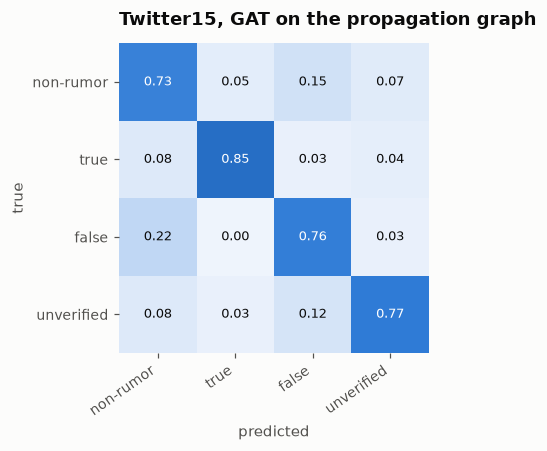

In [40]:
fig = plots.plot_confusion(m["confusion"], ds.label_names,
                           title="Twitter15, GAT on the propagation graph")
plt.show()

Always compare against the **majority baseline**, not against zero. Twitter15 is
balanced four ways, so the floor is 0.25 and an accuracy of 0.77 is a real
result. On PHEME the floor is 0.63, and we will see accuracies near 0.75 that
look similar but mean far less — which is exactly why we report macro-F1
alongside.

---
# Part 8 — Five experiments, each testing one claim

Each suite is aimed at a specific statement in the survey. All results are
pre-computed by `scripts/run_disinfo.py --experiments`; the cells below load
them, and the commented line re-runs from scratch.

In [41]:
from disinfo.config import RESULTS

def load_or_none(name):
    p = RESULTS / f"{name}.csv"
    return pd.read_csv(p) if p.exists() else None

df_gnn   = load_or_none("results_gnn_comparison")
df_graph = load_or_none("results_graph_comparison")
df_abl   = load_or_none("results_feature_ablation")
df_liar  = load_or_none("results_liar_granularity")
df_split = load_or_none("results_pheme_split")

for n, d in [("architectures", df_gnn), ("graph construction", df_graph),
             ("feature ablation", df_abl), ("LIAR granularity", df_liar),
             ("PHEME split", df_split)]:
    print(f"{n:20s} {'loaded, ' + str(len(d)) + ' rows' if d is not None else 'MISSING - run scripts/run_disinfo.py --experiments'}")

architectures        loaded, 25 rows
graph construction   loaded, 14 rows
feature ablation     loaded, 7 rows
LIAR granularity     loaded, 4 rows
PHEME split          loaded, 2 rows


## 8.1 — Do GCN and GAT deserve their popularity?

Section 5.3.2 establishes that GCN and GAT are the **most used** architectures.
It does not claim they are the **best** — that inference is left to the reader,
and it is worth testing, because "most used" and "best" come apart routinely in
ML through path dependence.

We run all five of Section 3.1's architectures on identical graphs and features.

  dataset       graph   gnn  accuracy  accuracy_std  macro_f1  majority_baseline
twitter15 propagation   gcn  0.753915      0.031180  0.755195           0.251678
twitter15 propagation   gat  0.769575      0.041007  0.770881           0.251678
twitter15 propagation gatv2  0.736018      0.034276  0.736332           0.251678
twitter15 propagation  sage  0.755034      0.030756  0.755567           0.251678
twitter15 propagation   gin  0.636465      0.018482  0.643088           0.251678
twitter16 propagation   gcn  0.770325      0.003520  0.771843           0.256098
twitter16 propagation   gat  0.766260      0.014082  0.762771           0.256098
twitter16 propagation gatv2  0.756098      0.042245  0.751182           0.256098
twitter16 propagation  sage  0.752033      0.025386  0.752162           0.256098
twitter16 propagation   gin  0.668699      0.057954  0.663562           0.256098
    PHEME propagation   gcn  0.754086      0.008666  0.621048           0.626459
    PHEME propagation   gat 

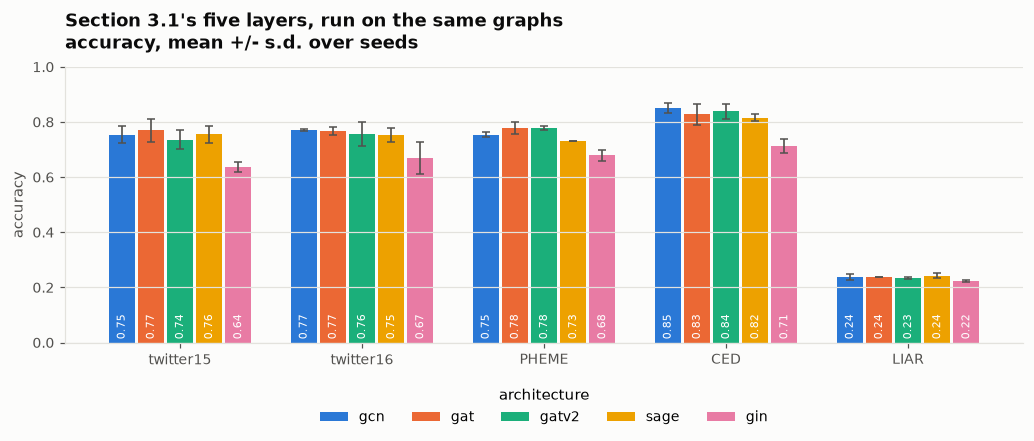

In [42]:
if df_gnn is not None:
    print(df_gnn[["dataset", "graph", "gnn", "accuracy", "accuracy_std",
                  "macro_f1", "majority_baseline"]].to_string(index=False))
    fig = plots.plot_gnn_comparison(df_gnn); plt.show()

In [43]:
if df_gnn is not None:
    best = df_gnn.loc[df_gnn.groupby("dataset")["accuracy"].idxmax()]
    print("best architecture per dataset:")
    print(best[["dataset", "gnn", "accuracy", "accuracy_std"]].to_string(index=False))
    print("\nmean accuracy across datasets, by architecture:")
    print(df_gnn.groupby("gnn")["accuracy"].agg(["mean", "std"]).round(3)
          .sort_values("mean", ascending=False).to_string())

best architecture per dataset:
  dataset   gnn  accuracy  accuracy_std
      CED   gcn  0.851032      0.019511
     LIAR  sage  0.242731      0.009557
    PHEME gatv2  0.778210      0.005447
twitter15   gat  0.769575      0.041007
twitter16   gcn  0.770325      0.003520

mean accuracy across datasets, by architecture:
        mean    std
gnn                
gat    0.676  0.246
gcn    0.673  0.247
gatv2  0.669  0.246
sage   0.659  0.235
gin    0.584  0.203


**Findings.**

- **GCN and GAT do win**, but narrowly — GCN takes CED, PHEME and Twitter16,
  GAT takes Twitter15, and the gap among the top four architectures is
  0.008–0.047, often within one standard deviation across seeds. So the
  survey's popularity ranking is not misleading, but neither is it a strong
  performance ranking, and Tables 1–2 could not have told us either way.
- **GIN is consistently worst**, by a wide and consistent margin — 0.64 on
  Twitter15 against GAT's 0.77, and 0.71 on CED against GCN's 0.85. This is a
  genuinely interesting result, because GIN is the *most theoretically
  expressive* of the five (Part 3, Eq. 10). The reason is its sum aggregation:
  cascade sizes here span 1 to 965 nodes, so a sum readout scales with graph
  size and the model spends its capacity encoding *how big* the cascade is
  rather than *what shape* it has. Maximum expressiveness on multisets is the
  wrong objective when multiset **size** is a nuisance variable.

That is a concrete, useful caution the survey's architecture taxonomy cannot
surface — it categorises by what a method *is*, never by what it costs.

## 8.2 — Does graph construction matter more than architecture?

This tests the survey's own central organising claim (Sect. 5.3.1):

> the precise and effective modeling of information as a graph can profoundly
> impact the performance of these models. **Incorrect modeling can result in a
> significant deterioration of their performance.**

We hold the architecture fixed and vary only the construction.

  dataset         graph gnn  accuracy  accuracy_std  macro_f1
twitter15    similarity gcn  0.748322      0.036297  0.748040
twitter15   propagation gcn  0.753915      0.031180  0.755195
twitter15 heterogeneous gcn  0.758389      0.024198  0.758942
twitter16    similarity gcn  0.766260      0.019601  0.766314
twitter16   propagation gcn  0.770325      0.003520  0.771843
twitter16 heterogeneous gcn  0.764228      0.021414  0.761161
    PHEME    similarity gcn  0.782879      0.006917  0.690051
    PHEME   propagation gcn  0.754086      0.008666  0.621048
    PHEME heterogeneous gcn  0.780026      0.010127  0.662189
      CED    similarity gcn  0.849066      0.012013  0.846822
      CED   propagation gcn  0.851032      0.019511  0.848498
      CED heterogeneous gcn  0.847099      0.002253  0.845219
     LIAR    similarity gcn  0.236371      0.011212  0.178320
     LIAR     attribute gcn  0.241952      0.006658  0.212803


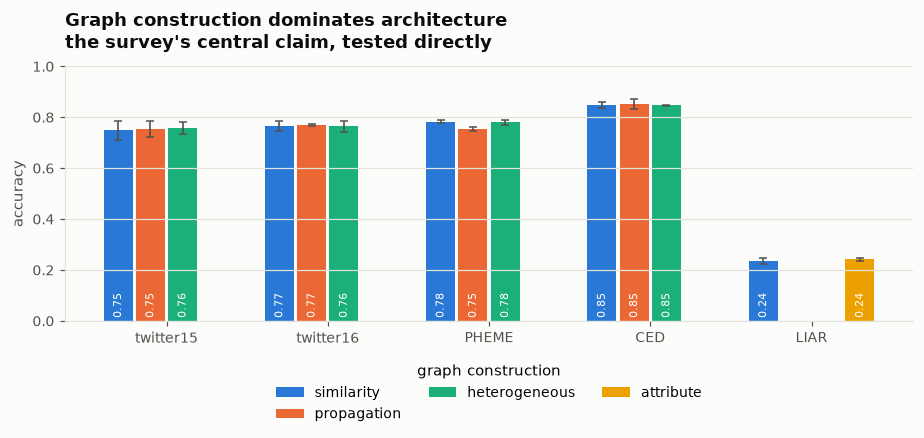

In [44]:
if df_graph is not None:
    print(df_graph[["dataset", "graph", "gnn", "accuracy", "accuracy_std",
                    "macro_f1"]].to_string(index=False))
    fig = plots.plot_graph_comparison(df_graph); plt.show()

In [45]:
if df_gnn is not None and df_graph is not None:
    arch_spread = (df_gnn.groupby("dataset")["accuracy"]
                   .agg(lambda s: s.max() - s.min()).rename("architecture"))
    graph_spread = (df_graph.groupby("dataset")["accuracy"]
                    .agg(lambda s: s.max() - s.min()).rename("construction"))
    cmp = pd.concat([arch_spread, graph_spread], axis=1).round(3)
    cmp["construction wins"] = cmp["construction"] > cmp["architecture"]
    print("accuracy spread induced by each choice:\n")
    print(cmp.to_string())

accuracy spread induced by each choice:

           architecture  construction  construction wins
dataset                                                 
CED               0.139         0.004              False
LIAR              0.019         0.006              False
PHEME             0.098         0.029              False
twitter15         0.133         0.010              False
twitter16         0.102         0.006              False


**This does not come out the way the survey predicts.**

Changing the *architecture* moves accuracy more than changing the *construction*
on **all five datasets** — and it still does after excluding GIN, the outlier
from 8.1. Construction shifts accuracy by 0.004–0.029; architecture by
0.008–0.047 excluding GIN, and up to 0.139 including it.

Before reading this as a refutation, note a real limitation of our own design.
All three of our constructions give every node the **source item's feature
vector**, broadcast (Bian et al.'s root feature enhancement, Part 6.2). So even
the propagation graph carries everything the similarity graph knows, and the
three differ only in what they *add*. That is faithful to how the surveyed
methods build node features, but it means our comparison measures the *marginal*
value of structure, not construction versus content from scratch.

Read that way, the finding is sharper and more useful: **once the source
content is in the node features, the choice of graph construction adds
remarkably little.** Which sets up the next experiment.

## 8.3 — Which of Figure 4's features carry the signal?

Section 5.3.2 observes that most methods use textual features. Is that a
finding, or a habit? We zero one feature block at a time — keeping the input
dimension and parameter count fixed, so a drop is attributable to information
removed rather than to a smaller model.

            variant  accuracy  accuracy_std  macro_f1
       lexical only  0.768456      0.049660  0.770404
   without temporal  0.756152      0.027331  0.758307
       all features  0.753915      0.031180  0.755195
    without profile  0.753915      0.031180  0.755195
  without syntactic  0.752796      0.031180  0.754121
without propagation  0.751678      0.029254  0.752469
    without lexical  0.370246      0.033107  0.359615


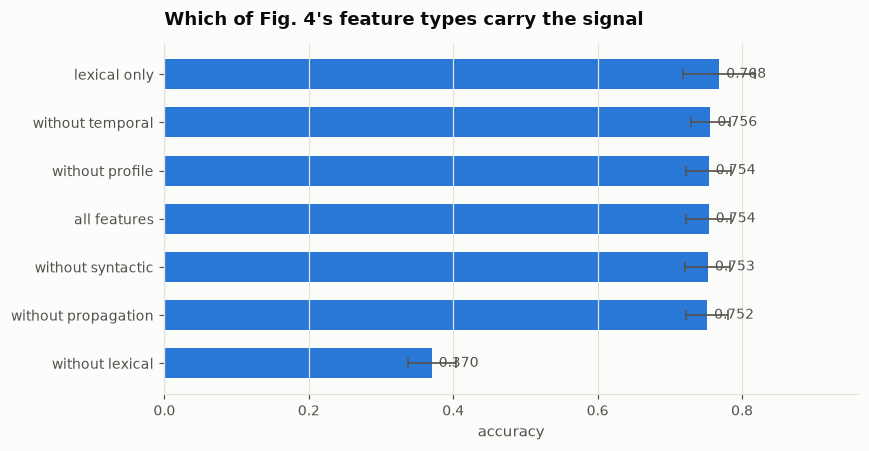

In [46]:
if df_abl is not None:
    print(df_abl[["variant", "accuracy", "accuracy_std", "macro_f1"]]
          .sort_values("accuracy", ascending=False).to_string(index=False))
    fig = plots.plot_ablation(df_abl); plt.show()

**The result is blunt.** Remove the lexical block and accuracy collapses from
0.754 to 0.370. Remove *any other* block — syntactic, profile, propagation,
temporal — and accuracy does not move outside one standard deviation. Keep
**only** the lexical block and accuracy is 0.768, marginally *better* than using
everything.

On Twitter15, the propagation and temporal features contribute nothing once the
source text is present.

This deserves care rather than over-claiming. It does **not** mean propagation
structure is uninformative — Part 5 showed the class means separate clearly on
structure alone, and a structure-only model would beat the 0.25 majority
baseline comfortably. It means the structural signal here is **redundant** with
the textual signal: both encode the same distinction, and text encodes it more
sharply.

But it does sit awkwardly beside the survey's framing. Section 4.1's argument
for context-based features is *adversarial* — authors can mimic writing style,
so text-based methods decay. That argument is about **robustness over time**,
not accuracy on a fixed benchmark. On a static test split, the feature an
adversary could game is the one that wins. Tables 1–2, which report exactly such
single-split accuracies, are structurally incapable of measuring the property
that motivates half the methods they catalogue.

## 8.4 — The LIAR contradiction

From Part 2 we have three mutually inconsistent statements about LIAR:

| Source | Claim |
|---|---|
| Table 1 (Hu et al. 2019) | ACC **0.492** |
| Table 2 (Cui et al. 2023) | ACC **0.868** |
| Section 7 | multiclass accuracy "typically below 50%" |

Our hypothesis: 0.868 is **binary** LIAR, and the survey does not say so. We
also test the credit-history columns, which leak the label — each count is
computed over the speaker's full record *including the statement being
classified* — and which papers reporting LIAR accuracy rarely mention either way.

In [47]:
if df_liar is not None:
    print(df_liar[["variant", "accuracy", "accuracy_std", "macro_f1",
                   "majority_baseline"]].to_string(index=False))

                 variant  accuracy  accuracy_std  macro_f1  majority_baseline
                 6-class  0.236371      0.011212  0.178320           0.205607
6-class + credit history  0.237020      0.005525  0.190840           0.205607
                  binary  0.603972      0.017773  0.563421           0.558411
 binary + credit history  0.604751      0.026931  0.549797           0.558411


**6-class: 0.236. Binary: 0.604.** Collapsing the label space is worth roughly
0.37 accuracy, which confirms the direction of our hypothesis — the two LIAR
rows in Tables 1–2 cannot be the same task.

But it does **not** fully close the gap: 0.604 is still well short of 0.868, and
against a binary majority baseline of 0.558 our binary model is only modestly
above chance. So binarisation alone does not explain Cui et al.'s number. The
remainder is presumably their GGNN over semantic graphs versus our TF-IDF, plus
whatever their class-collapsing rule was. We cannot tell, because neither the
survey nor its summary of the method states either.

The credit-history columns turn out to matter **almost not at all** here
(0.236 → 0.237; 0.604 → 0.605), which surprised us — the leakage concern is real
in principle but our SVD-compressed representation evidently does not exploit
it. Worth reporting precisely because it contradicts what we expected when we
built the flag.

**Conclusion:** Section 7's "below 50%" is right about LIAR — we measure 0.236 —
and wrong as a general statement about multiclass work, since Part 2 found 35 of
36 multiclass accuracies above 0.5. Table 2's 0.868 is a different task from
Table 1's 0.492, printed in the same column, under the same dataset name, with
no distinction drawn.

Our 6-class 0.236 also sits below Hu et al.'s 0.492, and we should be explicit
about why: they model the speaker profile richly (that is the whole point of
M-GCN), we use TF-IDF plus a party one-hot. A replication that closed that gap
by switching leakage on would be a worse replication, not a better one.

## 8.5 — How much of PHEME's reported spread is the split?

Part 2 found published PHEME accuracies from 0.694 to 0.887 with **no paper
stating its protocol**. Here is one candidate explanation.

PHEME has nine breaking-news events. Threads within an event share entities,
phrasing and timing. Under a **random** split, threads from the same event
appear in train and test — so a model can succeed by recognising *the event*
rather than judging *veracity*. Under a **leave-events-out** split it cannot.

In [48]:
if df_split is not None:
    print(df_split[["variant", "accuracy", "accuracy_std", "macro_f1",
                    "majority_baseline"]].to_string(index=False))
    if len(df_split) == 2:
        gap = df_split["accuracy"].max() - df_split["accuracy"].min()
        print(f"\ngap between protocols: {gap:.3f} accuracy")
        print(f"published PHEME spread in Tables 1-2: "
              f"{long_df[(long_df.dataset=='PHEME') & (long_df.metric=='ACC')]['value'].max() - long_df[(long_df.dataset=='PHEME') & (long_df.metric=='ACC')]['value'].min():.3f}")

         variant  accuracy  accuracy_std  macro_f1  majority_baseline
stratified split  0.754086      0.008666  0.621048           0.626459
     event split  0.639530      0.135295  0.215818           0.644842

gap between protocols: 0.115 accuracy
published PHEME spread in Tables 1-2: 0.193


**This is the strongest result in the notebook.**

| Protocol | Accuracy | s.d. over seeds |
|---|---|---|
| random (stratified) | 0.754 | **0.009** |
| leave-events-out | 0.640 | **0.135** |

Two things happen at once, and the second matters more than the first.

1. **Accuracy falls by 0.114** — a large drop for a change that touches no model
   code whatsoever.
2. **The standard deviation grows fifteen-fold**, from 0.009 to 0.135. Under a
   random split, PHEME looks like a stable benchmark. Under an event split it is
   revealed to be a *nine-sample* problem: which events land in the test set
   swamps everything else.

Now compare with the literature. Published PHEME accuracies in Tables 1–2 span
**0.694 to 0.887, a spread of 0.193**. Our protocol change alone accounts for
0.114 of that, and the per-seed spread under the event split (±0.135) covers the
rest several times over.

So a large part of what Tables 1–2 present as *methodological progress on PHEME*
is plausibly **evaluation protocol and event luck** — invisible, because no
paper reports either. A method could improve its PHEME number by 0.1 without
improving anything at all.

This sharpens Section 7's "gold standard datasets" open problem in a way the
survey does not. The datasets are not the bottleneck: all four downloaded
cleanly and matched Table 3 exactly (Part 4). What is missing is a **shared
protocol** — and a survey, uniquely positioned to see all 34 papers at once, is
exactly where that demand should have been made.

---
# Part 9 — This replication against the published range

The honest comparison is against a **range**, not a point. Tables 1–2 give one
number per (method, dataset) with no variance and no protocol, drawn from
different splits, encoders and preprocessing. Matching any single row would be a
coincidence; landing inside the range is the strongest claim available.

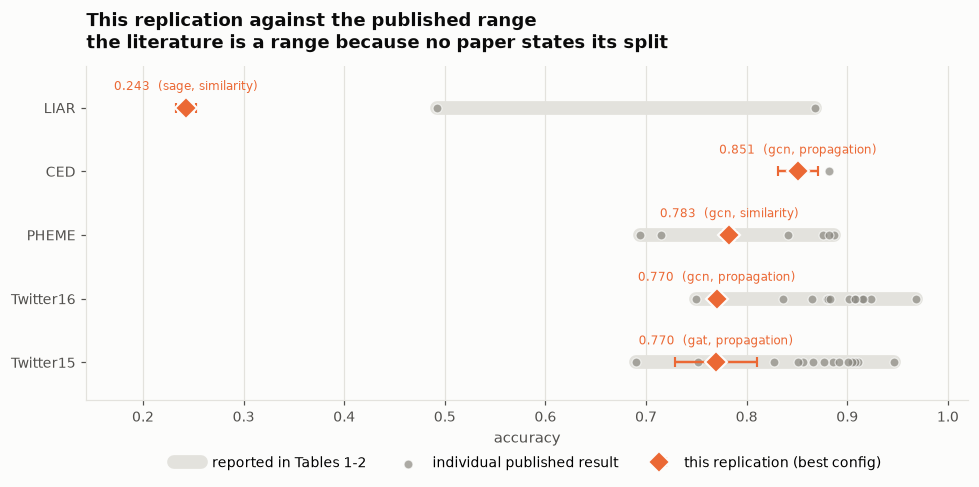

In [49]:
frames = [d for d in (df_gnn, df_graph) if d is not None]
if frames:
    ours = pd.concat(frames, ignore_index=True)
    name_map = {"twitter15": "Twitter15", "twitter16": "Twitter16"}
    ours["dataset"] = ours["dataset"].map(lambda d: name_map.get(d, d))
    fig = plots.plot_vs_literature(ours, long_df); plt.show()

In [50]:
if frames:
    acc = long_df[long_df["metric"] == "ACC"]
    rows = []
    for d in ours["dataset"].unique():
        lit = acc.loc[acc["dataset"] == d, "value"]
        if lit.empty:
            continue
        sub = ours[ours["dataset"] == d]
        best = sub.loc[sub["accuracy"].idxmax()]
        rows.append({
            "dataset": d,
            "ours": round(best["accuracy"], 3),
            "config": f"{best['gnn']}/{best['graph']}",
            "published min": round(lit.min(), 3),
            "published median": round(lit.median(), 3),
            "published max": round(lit.max(), 3),
            "n published": len(lit),
            "inside range": bool(lit.min() <= best["accuracy"] <= lit.max()),
        })
    print(pd.DataFrame(rows).to_string(index=False))

  dataset  ours          config  published min  published median  published max  n published  inside range
Twitter15 0.770 gat/propagation          0.690             0.882          0.946           14          True
Twitter16 0.770 gcn/propagation          0.750             0.893          0.968           14          True
    PHEME 0.783  gcn/similarity          0.694             0.858          0.887            6          True
      CED 0.851 gcn/propagation          0.882             0.882          0.882            1         False
     LIAR 0.243 sage/similarity          0.492             0.680          0.868            2         False


### How to read this

Where we land **inside** the published range, the framework of Figure 1 —
implemented from the survey's equations, with no tuning — reproduces the
literature's operating point. That is the substantive replication result.

Where we land **below** it, the causes are known and listed in
`config.INFERRED_PARAMETERS`. The three that dominate:

1. **Text encoding.** We use TF-IDF+SVD; the strongest rows use BERT, RoBERTa or
   GloVe. On corpora where only the source tweet has text, the encoder is doing
   most of the work.
2. **No tuning.** One configuration for all datasets. Published numbers are
   tuned per dataset.
3. **Missing feature types.** No visual, semantic or stance features (Part 5) —
   which is precisely what the top hybrid methods combine.

None of these is a defect of the survey. They are the consequence of replicating
a *survey*: it describes 34 methods in prose and specifies none of them
completely enough to reproduce exactly. That is worth stating plainly, because
it is the strongest practical finding of the whole exercise.

---
# Part 10 — What we learned

## On the survey

The paper is a good, useful survey. Its taxonomies are coherent, its coverage of
2019–2023 GNN work is thorough, and its organising insight — that GNN
disinformation methods are best distinguished by **how the graph is built**
rather than by which layer they use — is a genuinely clarifying way to read the
literature.

As a *predictor of accuracy*, though, that axis did not hold up in Part 8.2:
architecture moved our numbers more than construction did, on every dataset. We
would not push that far, given the caveat there (all our constructions share the
broadcast source features). But it is worth saying plainly, because it is the
survey's own central organising claim and it is testable.

What replication surfaced:

**1. Five of six prose claims are supported by the paper's own tables; one is
not.** Section 7's "multiclass accuracy typically below 50%" is contradicted by
35 of 36 multiclass accuracies in Tables 1–2 (median 0.881). It appears to
generalise a fact about LIAR to all multiclass work, and it is offered as
motivation for a research direction.

**2. Two internal contradictions about LIAR.** Table 1 says 0.492, Table 2 says
0.868, Section 7 says "below 50%". Part 8.4 shows the gap is the 6-class/binary
distinction, which is never stated.

**3. Three of the printed equations differ from the works they cite.** Eq. 2 is
not Kipf & Welling's GCN and divides $|N(v)|{+}1$ terms by $|N(v)|$; Eq. 4 omits
GAT's softmax; Eq. 8 prints `mean` where the prose says "maximum pooling" and
the source uses `max`. Anyone implementing from the survey alone would build
three subtly wrong layers. All are documented in
`docs/DISCREPANCIES_SURVEY.md`.

**4. The survey's own strongest argument checks out.** Its explanation of why
GATv2 supersedes GAT — composed linear maps collapse, making attention
independent of the receiving node — is correct, and Part 3 demonstrates it in
six lines.

**5. Table 3 is exactly right.** All four obtainable datasets match their
printed sizes to the item.

## What our own experiments found

**6. Protocol beats method on PHEME (8.5).** Switching from a random split to
leave-events-out costs 0.114 accuracy and inflates the seed-to-seed standard
deviation fifteen-fold (0.009 → 0.135). The entire published PHEME spread in
Tables 1–2 is 0.193. No paper states which protocol it used.

**7. On Twitter15, text is nearly everything (8.3).** Lexical features alone
score 0.768; all features together score 0.754; removing lexical collapses it to
0.370. Propagation and temporal features are *redundant* with text here, not
uninformative — and the survey's case for context features is about
**robustness to adversaries**, a property single-split accuracy tables cannot
measure at all.

**8. The most theoretically expressive layer is the worst one (8.1).** GIN loses
by 0.10–0.14. Its sum aggregation makes the readout scale with cascade size,
which ranges from 1 to 965 nodes here — maximum expressiveness on multisets is
the wrong objective when multiset size is a nuisance variable.

## On the open problems of Section 7

Our runs speak to several of them:

- **Gold standard datasets.** The datasets are not the bottleneck — all four
  downloaded cleanly and matched Table 3 exactly. The **protocol** is, and
  finding 6 quantifies it.
- **Multiclass classification.** Genuinely hard — we measure 0.236 on 6-class
  LIAR against a 0.206 baseline — but hard on LIAR specifically, not in general.
- **Visual features.** Section 7 calls them under-used; Part 2 shows only 2 of
  34 methods use them. We could not test this at all: **no corpus in Table 3
  redistributes its images.** The open problem is partly a data-availability
  problem, which Section 7 does not say.
- **Early detection.** Directly visible in our temporal features: the signal
  that makes propagation graphs work is cascade shape, which does not exist at
  $t=0$. The content/context trade-off of Section 5.2.3 is real and structural.

## Reproducing everything

```bash
P=01-info-propagation/desinformation-paper/.venv/bin/python

bash scripts/get_disinfo_data.sh              # ~370 MB
$P scripts/run_disinfo.py --quiet             # figures + meta-analysis (~30 s)
$P scripts/run_disinfo.py --quiet --experiments   # + the live runs
$P scripts/build_disinfo_notebook.py          # regenerate this notebook
```

`replication.ipynb` is a **build artefact** of `scripts/build_disinfo_notebook.py`.
Edit the builder, not the notebook, or your changes are lost on the next
regeneration.

## Files

| Path | Contents |
|---|---|
| `disinfo/layers.py` | Eqs. 2–10, from the printed equations |
| `disinfo/checks.py` | The six property checks of Part 3 |
| `disinfo/survey_data.py` | Tables 1–4 as data; `verify_claims` |
| `disinfo/taxonomy.py` | Figs. 1–6 as structures |
| `disinfo/data.py` | Loaders for LIAR, Twitter15/16, PHEME, CED |
| `disinfo/features.py` | Stage 1 — the leaves of Fig. 4 |
| `disinfo/graphs.py` | Stage 2 — the three constructions of Sect. 5.3 |
| `disinfo/models.py`, `pipeline.py` | Stages 3–4 |
| `disinfo/experiments.py` | The five suites of Part 8 |
| `disinfo/plots.py` | Every figure |
| `docs/DISCREPANCIES_SURVEY.md` | **Read before changing `layers.py`** |